# Формирование датасета 

In [1]:
pip install -q yfinance fredapi pandas_datareader


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
from fredapi import Fred
import pandas_datareader.data as web
from datetime import datetime
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

## ETF 

In [3]:
tickers = ['SPY', 'QQQ', 'TLT', 'GLD', 'EEM', 'DBC', 'IYR', 'UUP']
start_date = '2007-03-01' # тк раньше UUP не публиковался 
end_date = '2026-04-30'

raw = yf.download(tickers, start=start_date, end=end_date)

[*********************100%***********************]  8 of 8 completed


In [4]:
raw.head()

Price           Close                                                         \
Ticker            DBC        EEM        GLD        IYR        QQQ        SPY   
Date                                                                           
2007-03-01  20.329021  24.451200  65.820000  43.877262  36.985260  98.521225   
2007-03-02  20.142216  24.224648  63.709999  42.970467  36.427860  97.231049   
2007-03-05  19.841707  23.603331  62.930000  41.447437  36.144867  96.305542   
2007-03-06  20.028509  24.639610  64.150002  42.875275  36.745159  97.953293   
2007-03-07  20.304655  24.489334  64.300003  42.264038  36.599361  97.855057   

Price                                  High             ...       Open  \
Ticker            TLT        UUP        DBC        EEM  ...        TLT   
Date                                                    ...              
2007-03-01  49.563717  20.549210  20.442727  24.706906  ...  49.856404   
2007-03-02  49.812172  20.540977  20.353384  24.756245  ...  49.679635   
2007-03-05  49.895031  20.672649  19.963535  24.134928  ...  49.966825   
2007-03-06  49.745903  20.656195  20.101606  24.697929  ...  49.734856   
2007-03-07  49.939167  20.573896  20.345264  24.682234  ...  49.745883   

Price                  Volume                                          \
Ticker            UUP     DBC       EEM       GLD      IYR        QQQ   
Date                                                                    
2007-03-01  20.516292  169100  58851900   7108000  6614800  231806500   
2007-03-02  20.590356  295700  59927700  13732200  3777200  183359400   
2007-03-05  20.664420  658600  54968400   9829800  7783300  171885400   
2007-03-06  20.656195  143300  49910400   6992700  6600000  155551800   
2007-03-07  20.639733  533600  31768200   6131800  4870300  119979300   

Price                                 
Ticker            SPY      TLT   UUP  
Date                                  
2007-03-01  212828600  2423900  4600  
2007-03-02  162574000  1619800  2400  
2007-03-05  143750400  1505200  1100  
2007-03-06  143333300   837400   400  
2007-03-07  115144900   915400  2800  

[5 rows x 40 columns]

In [5]:
prices = raw['Close']
volumes = raw['Volume']

In [6]:
prices.columns = [f"{col}_price" for col in prices.columns]
prices = prices.reset_index().rename(columns={'Date': 'date'})
prices.head()

,date,DBC_price,EEM_price,GLD_price,IYR_price,QQQ_price,SPY_price,TLT_price,UUP_price
0,2007-03-01,20.329021,24.451200,65.820000,43.877262,36.985260,98.521225,49.563717,20.549210
1,2007-03-02,20.142216,24.224648,63.709999,42.970467,36.427860,97.231049,49.812172,20.540977
2,2007-03-05,19.841707,23.603331,62.930000,41.447437,36.144867,96.305542,49.895031,20.672649
3,2007-03-06,20.028509,24.639610,64.150002,42.875275,36.745159,97.953293,49.745903,20.656195
4,2007-03-07,20.304655,24.489334,64.300003,42.264038,36.599361,97.855057,49.939167,20.573896


In [7]:
volumes.columns = [f"{col}_volume" for col in volumes.columns]
volumes = volumes.reset_index().rename(columns={'Date': 'date'})
volumes.head()

,date,DBC_volume,EEM_volume,GLD_volume,IYR_volume,QQQ_volume,SPY_volume,TLT_volume,UUP_volume
0,2007-03-01,169100,58851900,7108000,6614800,231806500,212828600,2423900,4600
1,2007-03-02,295700,59927700,13732200,3777200,183359400,162574000,1619800,2400
2,2007-03-05,658600,54968400,9829800,7783300,171885400,143750400,1505200,1100
3,2007-03-06,143300,49910400,6992700,6600000,155551800,143333300,837400,400
4,2007-03-07,533600,31768200,6131800,4870300,119979300,115144900,915400,2800


объединим датафреймы

In [8]:
pr_vol_df = prices.merge(volumes, on='date', how='outer')

In [9]:
pr_vol_df.isna().sum()

date          0
DBC_price     0
EEM_price     0
GLD_price     0
IYR_price     0
QQQ_price     0
SPY_price     0
TLT_price     0
UUP_price     0
DBC_volume    0
EEM_volume    0
GLD_volume    0
IYR_volume    0
QQQ_volume    0
SPY_volume    0
TLT_volume    0
UUP_volume    0
dtype: int64

## Общерыночные индикаторы

In [10]:
vix = yf.download('^VIX', start=start_date, end=end_date)['Close']
vix.columns = ['vix_level']
vix = vix.reset_index().rename(columns={'Date': 'date'})

move = yf.download('^MOVE', start=start_date, end=end_date)['Close']
move.columns = ['move_index']
move = move.reset_index().rename(columns={'Date': 'date'})

dxy = yf.download('DX-Y.NYB', start=start_date, end=end_date)['Close']
dxy.columns = ['dxy_index']
dxy = dxy.reset_index().rename(columns={'Date': 'date'})

wti = yf.download('CL=F', start=start_date, end=end_date)['Close']
wti.columns = ['wti_price']
wti = wti.reset_index().rename(columns={'Date': 'date'})

brent = yf.download('BZ=F', start=start_date, end=end_date)['Close']
brent.columns = ['brent_price']
brent = brent.reset_index().rename(columns={'Date': 'date'})

ng = yf.download('NG=F', start=start_date, end=end_date)['Close']
ng.columns = ['ng_price']
ng = ng.reset_index().rename(columns={'Date': 'date'})

copper = yf.download('HG=F', start=start_date, end=end_date)['Close']
copper.columns = ['copper_price']
copper = copper.reset_index().rename(columns={'Date': 'date'})

usd_eur = yf.download('EURUSD=X', start=start_date, end=end_date)['Close']
usd_eur.columns = ['usd_eur']
usd_eur = usd_eur.reset_index().rename(columns={'Date': 'date'})

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [11]:
vix

,date,vix_level
0,2007-03-01,15.820000
1,2007-03-02,18.610001
2,2007-03-05,19.629999
3,2007-03-06,15.960000
4,2007-03-07,15.240000
...,...,...
4817,2026-04-23,19.309999
4818,2026-04-24,18.709999
4819,2026-04-27,18.020000
4820,2026-04-28,17.830000


объединим таблицы 

In [12]:
dfs = [vix, move, dxy, wti, brent, ng, copper, usd_eur]
ind_df = dfs[0]
for df in dfs[1:]:
    ind_df = ind_df.merge(df, on='date', how='outer')
ind_df = ind_df.sort_values('date')
ind_df

,date,vix_level,move_index,dxy_index,wti_price,brent_price,ng_price,copper_price,usd_eur
0,2007-03-01,15.820000,72.900002,83.680000,62.000000,NaN,7.288,2.7365,1.317003
1,2007-03-02,18.610001,76.699997,83.739998,61.639999,NaN,7.243,2.6930,1.316500
2,2007-03-05,19.629999,74.500000,84.150002,60.070000,NaN,7.254,2.6580,1.308695
3,2007-03-06,15.960000,67.099998,84.070000,60.689999,NaN,7.472,2.7010,1.313802
4,2007-03-07,15.240000,71.300003,83.779999,61.820000,NaN,7.366,2.7720,1.317853
...,...,...,...,...,...,...,...,...,...
4991,2026-04-23,19.309999,67.699997,98.800003,95.849998,105.070000,2.614,6.0755,1.170604
4992,2026-04-24,18.709999,66.970001,98.510002,94.400002,105.330002,2.523,6.0235,1.168388
4993,2026-04-27,18.020000,68.419998,98.480003,96.370003,108.230003,2.550,6.0180,1.170645
4994,2026-04-28,17.830000,68.680000,98.620003,99.930000,111.260002,2.559,5.9145,1.172347


In [13]:
ind_df.isna().sum()

date              0
vix_level       174
move_index      262
dxy_index       173
wti_price       174
brent_price     330
ng_price        173
copper_price    174
usd_eur          28
dtype: int64

в данных появились пропуски, тк какие-то показатели отсутствуют из-за праздников, например. заполним последним известным значением. 

In [14]:
ind_df = ind_df.sort_values('date').ffill()

In [15]:
ind_df.isna().sum()

date              0
vix_level         0
move_index        0
dxy_index         0
wti_price         0
brent_price     107
ng_price          0
copper_price      0
usd_eur           0
dtype: int64

данные brent начали публиковаться 2007-07-30. поэтому первые 107 строк – Nan

## Макроэкономические показатели 

In [ ]:
fred = Fred(api_key='FRED_API_KEY')


fred_series = {
    'T10Y2Y': 'spread_10y2y',
    'BAA10Y': 'baa_10y',
    'AAA10Y': 'aaa_10y',
    'STLFSI4': 'fin_stress',
    'CPIAUCSL': 'cpi_level',
    'CPILFESL': 'core_cpi_level',
    'PCEPI': 'pce_level',
    'PPIACO': 'ppi_level',
    'INDPRO': 'ind_prod',
    'UNRATE': 'unemp_rate',
    'FEDFUNDS': 'fed_funds_rate',
    'GDPC1': 'real_gdp',
    'T10YIE': 'breakeven_10y',
    'T5YIE': 'breakeven_5y',
    'DGS2': 'treasury_2y',
    'DGS5': 'treasury_5y',
    'DGS10': 'treasury_10y',
    'DGS30': 'treasury_30y',
    'DFII5': 'tips_5y',
    'DFII10': 'tips_10y',
    'DTB3': 'treasury_3m',
    'BAMLH0A0HYM2': 'hy_spread',
    'BAMLC0A0CM': 'ig_spread',
    'TEDRATE': 'ted_spread',
    'CPFF': 'commercial_paper_spread'}

macro = pd.DataFrame(index=pd.date_range(start=start_date, end=end_date, freq='D'))
for code, name in fred_series.items():
    s = fred.get_series(code, observation_start=start_date, observation_end=end_date)
    macro[name] = s

In [17]:
# Кредитный спред 
macro['credit_spread'] = macro['baa_10y'] - macro['aaa_10y']
macro.drop(['baa_10y', 'aaa_10y'], axis=1, inplace=True)

In [18]:
macro.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7001 entries, 2007-03-01 to 2026-04-30
Freq: D
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   spread_10y2y             4796 non-null   float64
 1   fin_stress               1000 non-null   float64
 2   cpi_level                228 non-null    float64
 3   core_cpi_level           228 non-null    float64
 4   pce_level                229 non-null    float64
 5   ppi_level                229 non-null    float64
 6   ind_prod                 229 non-null    float64
 7   unemp_rate               229 non-null    float64
 8   fed_funds_rate           230 non-null    float64
 9   real_gdp                 76 non-null     float64
 10  breakeven_10y            4796 non-null   float64
 11  breakeven_5y             4796 non-null   float64
 12  treasury_2y              4796 non-null   float64
 13  treasury_5y              4796 non-null   float64
 14

по hy_spread и ig_spread данных мало - их начали поздно публиковать. исключим их из датасета. также исключим ted_spread, тк данные есть только до 22 года 

In [19]:
macro = macro.drop(columns=['hy_spread', 'ig_spread', 'ted_spread'])

In [20]:
macro = macro.reset_index()
macro.rename(columns={'index': 'date'}, inplace=True)

In [21]:
macro = macro.sort_values('date')

In [22]:
# Заполняем пропуски (используем forw fill, то есть все пропуски заполняются прошлым)
macro.ffill(inplace=True)

In [23]:
macro.head()

,date,spread_10y2y,fin_stress,cpi_level,core_cpi_level,pce_level,ppi_level,ind_prod,unemp_rate,fed_funds_rate,...,breakeven_5y,treasury_2y,treasury_5y,treasury_10y,treasury_30y,tips_5y,tips_10y,treasury_3m,commercial_paper_spread,credit_spread
0,2007-03-01,-0.07,NaN,205.288,209.418,85.894,169.3,100.9547,4.4,5.26,...,2.39,4.63,4.50,4.56,4.68,2.11,2.19,5.00,-0.09,0.92
1,2007-03-02,-0.04,-0.6947,205.288,209.418,85.894,169.3,100.9547,4.4,5.26,...,2.40,4.56,4.46,4.52,4.65,2.06,2.15,4.98,0.00,0.93
2,2007-03-03,-0.04,-0.6947,205.288,209.418,85.894,169.3,100.9547,4.4,5.26,...,2.40,4.56,4.46,4.52,4.65,2.06,2.15,4.98,0.00,0.93
3,2007-03-04,-0.04,-0.6947,205.288,209.418,85.894,169.3,100.9547,4.4,5.26,...,2.40,4.56,4.46,4.52,4.65,2.06,2.15,4.98,0.00,0.93
4,2007-03-05,-0.02,-0.6947,205.288,209.418,85.894,169.3,100.9547,4.4,5.26,...,2.39,4.53,4.45,4.51,4.64,2.06,2.17,4.97,-0.08,0.95


In [24]:
macro.isna().sum()

date                        0
spread_10y2y                0
fin_stress                  1
cpi_level                   0
core_cpi_level              0
pce_level                   0
ppi_level                   0
ind_prod                    0
unemp_rate                  0
fed_funds_rate              0
real_gdp                   31
breakeven_10y               0
breakeven_5y                0
treasury_2y                 0
treasury_5y                 0
treasury_10y                0
treasury_30y                0
tips_5y                     0
tips_10y                    0
treasury_3m                 0
commercial_paper_spread     0
credit_spread               0
dtype: int64

пропуски в поле real_gdp объясняются тем, что данные были опубликованы раньше, и в дф не вошли. то есть ffill нечего взять для заполнения вперед. аналогично с fin_stress. итоговый дф приедтся обрезать, так что эти пропуски уйдут 

## Геополитические индексы 

In [25]:
pip install xlrd


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [26]:
df = pd.read_excel('data/data_gpr_daily_recent.xls', sheet_name='Sheet1')

In [27]:
df = df[['GPRD','date']]

GPR_d = df[(df['date'] >= start_date) &  (df['date'] <= end_date)]

In [28]:
GPR_d

,GPRD,date
8094,99.484581,2007-03-01
8095,127.292587,2007-03-02
8096,70.258705,2007-03-03
8097,41.691357,2007-03-04
8098,124.788513,2007-03-05
...,...,...
15090,167.390396,2026-04-26
15091,139.863968,2026-04-27
15092,249.333054,2026-04-28
15093,252.766205,2026-04-29


In [29]:
df = pd.read_excel('data/US_Policy_Uncertainty_Data.xlsx')

In [30]:
df = df[pd.to_numeric(df['Year'], errors='coerce').notna()]
df['Year'] = df['Year'].astype(int)
df['Month'] = df['Month'].astype(int)

в качестве даты возьмем последний день месяца. при содединении данных используй ffil, чтобы избежать утечки

In [31]:

df['date'] = pd.to_datetime(df[['Year', 'Month']].assign(day=1))
df['date'] = df['date'] + pd.offsets.MonthEnd(0)  # последний день месяца
EPU = df[['date', 'News_Based_Policy_Uncert_Index']]
EPU.columns = ['date', 'EPU']
EPU = EPU[(EPU['date'] >= start_date) &  (EPU['date'] <= end_date)]
EPU

,date,EPU
0,2026-03-31,382.222429
1,2026-02-28,374.191792
2,2026-01-31,371.334964
3,2025-12-31,288.594991
4,2025-11-30,311.649847
...,...,...
224,2007-07-31,44.782751
225,2007-06-30,68.759233
226,2007-05-31,71.137320
227,2007-04-30,59.841394


In [32]:
df = pd.read_excel('data/WUI_Data.xlsx', sheet_name='F1')

данные предтставлены по кварталам. чтобы избежать утечки, для каждого квартала поставим последнюю дату этого квартала. тогда мы будем использовать только доступную информацию

In [33]:
WUI = df.copy()
WUI = WUI[WUI.iloc[:, 0].astype(str).str.match(r'^\d{4}q[1-4]$', na=False)]
WUI = WUI.iloc[:, [0, 2]]
WUI.columns = ['quarter', 'wui']
WUI['date'] = pd.PeriodIndex(WUI['quarter'], freq='Q').to_timestamp(how='end').normalize()
WUI = WUI[['date', 'wui']].sort_values('date')
WUI = WUI[(WUI['date'] >= start_date) &  (WUI['date'] <= end_date)]
WUI

,date,wui
70,2007-03-31,13357.51
71,2007-06-30,18459.61
72,2007-09-30,21867.71
73,2007-12-31,13843.68
74,2008-03-31,13176.87
...,...,...
142,2025-03-31,48145.7
143,2025-06-30,80038.14
144,2025-09-30,106862.2
145,2025-12-31,94947.06


In [34]:
df = pd.read_csv('data/All_Daily_TPU_Data.csv')

In [ ]:
TPU = df.copy()

TPU['date'] = pd.to_datetime({'year': TPU['year'], 'month': TPU['month'], 'day': TPU['day']})

TPU = TPU[['date', 'daily_tpu_index']].sort_values('date')
TPU.columns = ['date', 'TPU']
TPU = TPU[(TPU['date'] >= start_date) &  (TPU['date'] <= end_date)]
TPU

,date,TPU
8094,2007-03-01,15.40
8095,2007-03-02,24.96
8096,2007-03-03,35.50
8097,2007-03-04,45.97
8098,2007-03-05,23.40
...,...,...
15090,2026-04-26,1054.53
15091,2026-04-27,458.47
15092,2026-04-28,1109.67
15093,2026-04-29,747.90


In [36]:
geopol_df = GPR_d.merge(TPU, on='date', how='left')
geopol_df = geopol_df.merge(EPU, on='date', how='left')
geopol_df = geopol_df.merge(WUI, on='date', how='left')

geopol_df = geopol_df.sort_values('date')
geopol_df = geopol_df.ffill()

In [37]:
geopol_df.head()

,GPRD,date,TPU,EPU,wui
0,99.484581,2007-03-01,15.40,NaN,NaN
1,127.292587,2007-03-02,24.96,NaN,NaN
2,70.258705,2007-03-03,35.50,NaN,NaN
3,41.691357,2007-03-04,45.97,NaN,NaN
4,124.788513,2007-03-05,23.40,NaN,NaN


очевидно, что первый квартал в поле wui будет Nan, тк к этому моменту данных нет. Позже удалим эти пропуски. 

## Объединение данных

на данных момент есть следующие датафреймы: pr_vol_df, ind_df, macro и geopol_df. Все они имеют общее поле date, причем везде даты - это каждый день, а не квартал или месяц 

In [38]:
base = pd.DataFrame({'date': pd.date_range(start=start_date, end=end_date, freq='D')})

data = base.merge(ind_df, on='date', how='left')
data = data.merge(pr_vol_df, on='date', how='left')
data = data.merge(macro, on='date', how='left')
data = data.merge(geopol_df, on='date', how='left')
data = data.sort_values('date').reset_index(drop=True)

In [39]:
data

,date,vix_level,move_index,dxy_index,wti_price,brent_price,ng_price,copper_price,usd_eur,DBC_price,...,treasury_30y,tips_5y,tips_10y,treasury_3m,commercial_paper_spread,credit_spread,GPRD,TPU,EPU,wui
0,2007-03-01,15.820000,72.900002,83.680000,62.000000,NaN,7.288,2.7365,1.317003,20.329021,...,4.68,2.11,2.19,5.00,-0.09,0.92,99.484581,15.40,NaN,NaN
1,2007-03-02,18.610001,76.699997,83.739998,61.639999,NaN,7.243,2.6930,1.316500,20.142216,...,4.65,2.06,2.15,4.98,0.00,0.93,127.292587,24.96,NaN,NaN
2,2007-03-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.65,2.06,2.15,4.98,0.00,0.93,70.258705,35.50,NaN,NaN
3,2007-03-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.65,2.06,2.15,4.98,0.00,0.93,41.691357,45.97,NaN,NaN
4,2007-03-05,19.629999,74.500000,84.150002,60.070000,NaN,7.254,2.6580,1.308695,19.841707,...,4.64,2.06,2.17,4.97,-0.08,0.95,124.788513,23.40,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6996,2026-04-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.91,1.31,1.89,3.60,0.09,0.60,167.390396,1054.53,382.222429,81871.73
6997,2026-04-27,18.020000,68.419998,98.480003,96.370003,108.230003,2.550,6.0180,1.170645,30.090000,...,4.94,1.32,1.91,3.60,0.17,0.59,139.863968,458.47,382.222429,81871.73
6998,2026-04-28,17.830000,68.680000,98.620003,99.930000,111.260002,2.559,5.9145,1.172347,30.340000,...,4.94,1.34,1.92,3.60,0.17,0.59,249.333054,1109.67,382.222429,81871.73
6999,2026-04-29,18.809999,74.330002,98.919998,106.879997,118.029999,2.647,5.8785,1.171783,31.080000,...,4.98,1.38,1.96,3.60,0.17,0.58,252.766205,747.90,382.222429,81871.73


In [40]:
data.isna().sum()

date                          0
vix_level                  2005
move_index                 2005
dxy_index                  2005
wti_price                  2005
brent_price                2112
ng_price                   2005
copper_price               2005
usd_eur                    2005
DBC_price                  2179
EEM_price                  2179
GLD_price                  2179
IYR_price                  2179
QQQ_price                  2179
SPY_price                  2179
TLT_price                  2179
UUP_price                  2179
DBC_volume                 2179
EEM_volume                 2179
GLD_volume                 2179
IYR_volume                 2179
QQQ_volume                 2179
SPY_volume                 2179
TLT_volume                 2179
UUP_volume                 2179
spread_10y2y                  0
fin_stress                    1
cpi_level                     0
core_cpi_level                0
pce_level                     0
ppi_level                     0
ind_prod

пропуски в поля DBC_price и тд (которых больше 2 тысяч), связаны с тем, что данные в выходные и праздники не публикуются. до этого момента я сохранял все даты, чтобы корректно получить real_gdp и другие квартальные/ежемесячные показатели, тк они публикуются не всегда в рабочие дни. дальше я сотавлю в датасете только рабочие дни, чтобы в данных не было искусственных точек (тк все выходные по сути дублируют последний рабочий день). но перед этим сделаем ffill, чтобы убрать технические пропуски, если такие есть 

In [41]:
data = data.ffill()

In [42]:
data.isna().sum()

date                         0
vix_level                    0
move_index                   0
dxy_index                    0
wti_price                    0
brent_price                151
ng_price                     0
copper_price                 0
usd_eur                      0
DBC_price                    0
EEM_price                    0
GLD_price                    0
IYR_price                    0
QQQ_price                    0
SPY_price                    0
TLT_price                    0
UUP_price                    0
DBC_volume                   0
EEM_volume                   0
GLD_volume                   0
IYR_volume                   0
QQQ_volume                   0
SPY_volume                   0
TLT_volume                   0
UUP_volume                   0
spread_10y2y                 0
fin_stress                   1
cpi_level                    0
core_cpi_level               0
pce_level                    0
ppi_level                    0
ind_prod                     0
unemp_ra

остались только пропуски в начале датафрейма 

теперь удалим первые 151 строк, тк brent_price до этого момента не публиковался. 

In [43]:
data = data.iloc[151:].reset_index(drop=True)

In [44]:
data.isna().sum()

date                       0
vix_level                  0
move_index                 0
dxy_index                  0
wti_price                  0
brent_price                0
ng_price                   0
copper_price               0
usd_eur                    0
DBC_price                  0
EEM_price                  0
GLD_price                  0
IYR_price                  0
QQQ_price                  0
SPY_price                  0
TLT_price                  0
UUP_price                  0
DBC_volume                 0
EEM_volume                 0
GLD_volume                 0
IYR_volume                 0
QQQ_volume                 0
SPY_volume                 0
TLT_volume                 0
UUP_volume                 0
spread_10y2y               0
fin_stress                 0
cpi_level                  0
core_cpi_level             0
pce_level                  0
ppi_level                  0
ind_prod                   0
unemp_rate                 0
fed_funds_rate             0
real_gdp      

пропуски устранены 

In [45]:
data.head()

,date,vix_level,move_index,dxy_index,wti_price,brent_price,ng_price,copper_price,usd_eur,DBC_price,...,treasury_30y,tips_5y,tips_10y,treasury_3m,commercial_paper_spread,credit_spread,GPRD,TPU,EPU,wui
0,2007-07-30,20.870001,97.900002,80.849998,76.830002,75.739998,6.499,3.5920,1.371197,21.100599,...,4.97,2.47,2.49,4.82,-0.04,1.05,97.773544,32.64,68.759233,18459.61
1,2007-07-31,23.520000,96.400002,80.769997,78.209999,77.050003,6.191,3.6535,1.367204,21.271154,...,4.92,2.43,2.44,4.82,-0.02,1.01,129.904617,6.41,44.782751,18459.61
2,2007-08-01,23.670000,94.300003,80.870003,76.529999,75.349998,6.352,3.5950,1.367708,21.238667,...,4.90,2.43,2.44,4.75,-0.07,1.01,124.139610,128.70,44.782751,18459.61
3,2007-08-02,21.219999,92.000000,80.709999,76.860001,75.760002,6.106,3.5750,1.370708,21.271154,...,4.91,2.47,2.46,4.75,0.00,1.00,95.069206,27.40,44.782751,18459.61
4,2007-08-03,25.160000,95.400002,80.180000,75.480003,74.750000,6.090,3.4845,1.378702,21.035620,...,4.87,2.41,2.44,4.72,0.01,0.90,122.339142,5.06,44.782751,18459.61


теперь оставим только рабочие дни, чтобы избежать большого числа дубликатов. для этого используем библиотеку, где хранятся дни, в которые биржа работает (возьмем Нью-Йоркскую фондовую биржу для этих целей)

In [46]:
pip install -q pandas_market_calendars


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [47]:
import pandas_market_calendars as mcal

# Получаем рабочие дни NYSE за нужный диапазон
data['date'] = pd.to_datetime(data['date'])
nyse = mcal.get_calendar('NYSE')
schedule = nyse.schedule(start_date=start_date, end_date=end_date)
trading_days = pd.to_datetime(schedule.index)

In [48]:
print(len(data))
# Фильтруем – оставляем только те даты, которые есть в trading_days
data = data[data['date'].isin(trading_days)].reset_index(drop=True)
len(data)

6850


4719

это как раз те пропуски, которые были ценах, объемах и индексах 

## Новые признаки   

здесь будет много коррелированных признаков. набор явно избыточный, но дальше я проведу отбор наиболее важных

In [49]:
def add_volume_features(df, tickers, windows=[5, 21, 63, 252]):
    """
    Добавляет объёмные признаки для каждого тикера.
    Признаки:
      - vol_ratio_{w}: отношение объёма к его скользящему среднему за w дней.
      - vol_trend_{w}: процентное изменение скользящего среднего объёма за w дней.
      - vol_vol_{w}: стандартное отклонение объёма за w дней.
    Все используют только прошлые данные (до t включительно).
    """
    for tkr in tickers:
        vol = df[f'{tkr}_volume']
        for w in windows:
            # Скользящее среднее объёма (окно заканчивается в t, без сдвига)
            vol_ma = vol.rolling(w, min_periods=max(1, w//2)).mean()
            # Отношение текущего объёма к среднему
            df[f'{tkr}_vol_ratio_{w}'] = vol / vol_ma
            # Изменение среднего объёма за 5 дней (тренд)
            if w >= 5:
                df[f'{tkr}_vol_trend_{w}'] = vol_ma.pct_change(5)
            # Стандартное отклонение объёма
            df[f'{tkr}_vol_sigma_{w}'] = vol.rolling(w, min_periods=max(1, w//2)).std()
    return df

In [50]:
add_volume_features(data, tickers)
for tkr in tickers:
    data.drop(columns=[f'{tkr}_volume'], inplace=True)
data.shape

(4719, 138)

In [51]:
def add_momentum_features(df, tickers, windows=[1, 5, 21, 63, 252]):
    for tkr in tickers:
        price = df[f'{tkr}_price']
        for w in windows:
            df[f'{tkr}_mom_{w}'] = price.pct_change(w)  # доходность за w дней
    return df

In [52]:
add_momentum_features(data, tickers)
data.shape

(4719, 178)

In [53]:
def add_max_drawdown(df, tickers, windows=[21, 63, 252]):
    """
    считает максимальное падение за послдение w дней
    """
    for tkr in tickers:
        price = df[f'{tkr}_price']
        for w in windows:
            peak = price.rolling(w, min_periods=1).max()
            df[f'{tkr}_mdd_{w}'] = (price - peak) / peak
    return df

In [54]:
add_max_drawdown(data, tickers)
data.shape

(4719, 202)

In [55]:
list(data.columns)

['date',
 'vix_level',
 'move_index',
 'dxy_index',
 'wti_price',
 'brent_price',
 'ng_price',
 'copper_price',
 'usd_eur',
 'DBC_price',
 'EEM_price',
 'GLD_price',
 'IYR_price',
 'QQQ_price',
 'SPY_price',
 'TLT_price',
 'UUP_price',
 'spread_10y2y',
 'fin_stress',
 'cpi_level',
 'core_cpi_level',
 'pce_level',
 'ppi_level',
 'ind_prod',
 'unemp_rate',
 'fed_funds_rate',
 'real_gdp',
 'breakeven_10y',
 'breakeven_5y',
 'treasury_2y',
 'treasury_5y',
 'treasury_10y',
 'treasury_30y',
 'tips_5y',
 'tips_10y',
 'treasury_3m',
 'commercial_paper_spread',
 'credit_spread',
 'GPRD',
 'TPU',
 'EPU',
 'wui',
 'SPY_vol_ratio_5',
 'SPY_vol_trend_5',
 'SPY_vol_sigma_5',
 'SPY_vol_ratio_21',
 'SPY_vol_trend_21',
 'SPY_vol_sigma_21',
 'SPY_vol_ratio_63',
 'SPY_vol_trend_63',
 'SPY_vol_sigma_63',
 'SPY_vol_ratio_252',
 'SPY_vol_trend_252',
 'SPY_vol_sigma_252',
 'QQQ_vol_ratio_5',
 'QQQ_vol_trend_5',
 'QQQ_vol_sigma_5',
 'QQQ_vol_ratio_21',
 'QQQ_vol_trend_21',
 'QQQ_vol_sigma_21',
 'QQQ_vol_ratio

## Стационарность 

### Стационарность цен активов

In [56]:
data_copy = data.copy()

In [57]:
# сохраним сырые цены 
prices_raw = data[[f'{tkr}_price' for tkr in tickers]].copy()

теперь нужно сделать ряд цен активов стацонарным. для этого сначала логарифмируем цены, а после применим метод FFD, описанный в книге. Код взят тоже из книги, но немного модифицирован

In [58]:
from statsmodels.tsa.stattools import adfuller

In [59]:
def getWeights_FFD(d, thres=1e-5):
    """
    Возвращает веса w_k для FFD, обрезая их, когда |w_k| < thres.
    d - дробный порядок, thres - порог отсечения (после него мы память обрубается).
    """
    w = [1.0]
    k = 1
    while True:
        w_ = -w[-1] * (d - k + 1) / k
        if abs(w_) < thres:
            break
        w.append(w_)
        k += 1
    return np.array(w)

In [60]:
def fracDiff_FFD(series, d, thres=1e-3):
    """
    Фиксированное окно FFD.
    series - логарифм цены,
    d - дробный порядок,
    thres - порог для обрезки весов. Значение взято из книги
    Возвращает pd.Series с тем же индексом.
    """
    w = getWeights_FFD(d, thres)
    width = len(w) - 1
    s = series.values
    result = np.full(len(s), np.nan)
    for i in range(width, len(s)):
        window = s[i-width : i+1]      # от старого к новому
        window = window[::-1]          # от нового к старому
        result[i] = np.dot(w, window)
    return pd.Series(result, index=series.index)


In [61]:
def find_optimal_d(log_price_series, d_range=(0, 1), step=0.01, thres=1e-3):
    """
    Подбирает минимальный d, при котором ряд становится стационарным (ADF p<0.05).
    Если ни одно d не подходит, возвращает 1.0 (обычные доходности).
    """
    best_d = None
    for d in np.arange(d_range[0], d_range[1] + step, step):
        ffd_series = fracDiff_FFD(log_price_series, d, thres).dropna()
        if len(ffd_series) < 20:
            continue
        try:
            stat, pval, _, _, _, _ = adfuller(ffd_series, maxlag=5, autolag='AIC') # adf-тест на стац-ть
        except:
            continue
        if pval < 0.05:
            best_d = d
            break
    return best_d if best_d is not None else 1.0

In [62]:
for tkr in tickers:
    # логарифм цены для сглаживания (стабилизирует дисперсию) 
    log_price = np.log(data[f'{tkr}_price'].astype(float))
    # лучшее d
    d_opt = find_optimal_d(log_price)
    print(f"{tkr}: optimal d = {d_opt:.3f}")
    # FFD
    data[f'{tkr}_ffd'] = fracDiff_FFD(log_price, d_opt)

# исходные столбцы больше не нужны 
data.drop([f'{tkr}_price' for tkr in tickers], axis=1, inplace=True)

SPY: optimal d = 0.510
QQQ: optimal d = 0.550
TLT: optimal d = 0.230
GLD: optimal d = 0.330
EEM: optimal d = 0.150
DBC: optimal d = 0.250
IYR: optimal d = 0.300
UUP: optimal d = 0.280


In [63]:
data[[f'{tkr}_ffd' for tkr in tickers]].head(80)

,SPY_ffd,QQQ_ffd,TLT_ffd,GLD_ffd,EEM_ffd,DBC_ffd,IYR_ffd,UUP_ffd
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
75,0.394644,0.270190,1.240372,0.835322,1.696760,0.895024,0.806958,0.715614
76,0.379571,0.241710,1.241397,0.850105,1.691935,0.922892,0.783137,0.716625
77,0.364527,0.242149,1.250177,0.816234,1.666899,0.909386,0.779498,0.719281
78,0.373444,0.255996,1.249004,0.821858,1.681875,0.913964,0.762380,0.717461


получили стационарность при сохранении памяти  

проверим корреляцию исходного ряда и ряда после ffd 

In [64]:
ffd_df = data[['date', 'SPY_ffd']].copy()
price_df = prices[['date', 'SPY_price']].copy()  

merged = pd.merge(ffd_df, price_df, on='date', how='inner')
merged.dropna(subset=['SPY_ffd', 'SPY_price'], inplace=True)
log_price = np.log(merged['SPY_price'])
ffd_vals = merged['SPY_ffd']

corr = np.corrcoef(log_price, ffd_vals)[0, 1]
print(f"корреляция FFD с логарифмом цены: {corr:.6f}")

корреляция FFD с логарифмом цены: 0.973177


In [65]:
ffd_df = data[['date', 'EEM_ffd']].copy()
price_df = prices[['date', 'EEM_price']].copy()  

merged = pd.merge(ffd_df, price_df, on='date', how='inner')
merged.dropna(subset=['EEM_ffd', 'EEM_price'], inplace=True)
log_price = np.log(merged['EEM_price'])
ffd_vals = merged['EEM_ffd']

corr = np.corrcoef(log_price, ffd_vals)[0, 1]
print(f"корреляция FFD с логарифмом цены: {corr:.6f}")

корреляция FFD с логарифмом цены: 0.990672


In [66]:
ffd_df = data[['date', 'UUP_ffd']].copy()
price_df = prices[['date', 'UUP_price']].copy()  

merged = pd.merge(ffd_df, price_df, on='date', how='inner')
merged.dropna(subset=['UUP_ffd', 'UUP_price'], inplace=True)
log_price = np.log(merged['UUP_price'])
ffd_vals = merged['UUP_ffd']

corr = np.corrcoef(log_price, ffd_vals)[0, 1]
print(f"корреляция FFD с логарифмом цены: {corr:.6f}")

корреляция FFD с логарифмом цены: 0.981445


корреляция между исходными рядами и ffd близка к 1

### Стационарность макро-показателей

можно было это сделать еще про формировании датасета, но я решил, что в этом разделе это более уместно

показатели, которые нужно сделать стационарными, исходя из логики:   
cpi_level  
core_cpi_level  
pce_level  
ppi_level   
fed_funds_rate     
ind_prod  
real_gdp  
unemp_rate  
fin_stress  

In [67]:
def get_fred_series(code, new_name):
    s = fred.get_series(code, observation_start=start_date, observation_end=end_date)

    s = s.to_frame(new_name)
    s = s.reset_index()
    s = s.rename(columns={'index': 'date'})
    s['date'] = pd.to_datetime(s['date'])

    return s


# CPI: месячный ряд, считаем изменение за год 
cpi = get_fred_series('CPIAUCSL', 'cpi_level')
cpi['cpi_yoy'] = cpi['cpi_level'].pct_change(12) * 100
cpi = cpi[['date', 'cpi_yoy']]

core_cpi = get_fred_series('CPILFESL', 'core_cpi_level')
core_cpi['core_cpi_yoy'] = core_cpi['core_cpi_level'].pct_change(12) * 100
core_cpi = core_cpi[['date', 'core_cpi_yoy']]

pce = get_fred_series('PCEPI', 'pce_level')
pce['pce_yoy'] = pce['pce_level'].pct_change(12) * 100
pce = pce[['date', 'pce_yoy']]

ppi = get_fred_series('PPIACO', 'ppi_level')
ppi['ppi_yoy'] = ppi['ppi_level'].pct_change(12) * 100
ppi = ppi[['date', 'ppi_yoy']]


# Prod: месячный ряд, считаем MoM
ind_prod = get_fred_series('INDPRO', 'ind_prod')
ind_prod['ind_prod_mom'] = ind_prod['ind_prod'].pct_change() * 100
ind_prod = ind_prod[['date', 'ind_prod_mom']]


# GDP: квартальный ряд, считаем QoQ
real_gdp = get_fred_series('GDPC1', 'real_gdp')
real_gdp['real_gdp_qoq'] = real_gdp['real_gdp'].pct_change() * 100
real_gdp = real_gdp[['date', 'real_gdp_qoq']]


# unemp: месячный ряд, изменение в процентных пунктах
unemp = get_fred_series('UNRATE', 'unemp_rate')
unemp['unemp_rate_diff'] = unemp['unemp_rate'].diff()
unemp = unemp[['date', 'unemp_rate_diff']]


# fin_stress: недельный ряд, изменение индекса
fin_stress = get_fred_series('STLFSI4', 'fin_stress')
fin_stress['fin_stress_diff'] = fin_stress['fin_stress'].diff()
fin_stress = fin_stress[['date', 'fin_stress_diff']]

fed = get_fred_series('FEDFUNDS', 'fed_funds_rate')
fed['fed_funds_diff'] = fed['fed_funds_rate'].diff()
fed = fed[['date', 'fed_funds_diff']]

In [68]:
macro_stationary_list = [
    cpi,
    core_cpi,
    pce,
    ppi,
    ind_prod,
    fed, 
    real_gdp,
    unemp,
    fin_stress]

In [69]:
# проверим стационарнсоть 

for df in macro_stationary_list:
    col = df.columns[1]   
    s = df[col].dropna()
    p = adfuller(s)[1]
    print(col, round(p,4))

cpi_yoy 0.2099
core_cpi_yoy 0.4361
pce_yoy 0.1368
ppi_yoy 0.0028
ind_prod_mom 0.0
fed_funds_diff 0.0059
real_gdp_qoq 0.0
unemp_rate_diff 0.0
fin_stress_diff 0.0


cpi_yoy, core_cpi_yoy, pce_yoy оказались нестационарными. дифф-м второй раз

In [70]:
cpi['cpi_yoy_diff'] = cpi['cpi_yoy'].diff()
core_cpi['core_cpi_yoy_diff'] = core_cpi['core_cpi_yoy'].diff()
pce['pce_yoy_diff'] = pce['pce_yoy'].diff()

In [71]:
cpi = cpi.drop(columns=['cpi_yoy'])
core_cpi = core_cpi.drop(columns=['core_cpi_yoy'])
pce = pce.drop(columns=['pce_yoy'])

In [72]:
temp_list = [cpi, core_cpi, pce]

for df in temp_list:
    col = df.columns[1]   
    s = df[col].dropna()
    p = adfuller(s)[1]
    print(col, round(p,4))

cpi_yoy_diff 0.0001
core_cpi_yoy_diff 0.0005
pce_yoy_diff 0.0001


теперь ряды стационарны

In [73]:
# перезапишем новые cpi, core_cpi, pce
macro_stationary_list = [
    cpi,
    core_cpi,
    pce,
    ppi,
    ind_prod,
    fed, 
    real_gdp,
    unemp,
    fin_stress]

In [74]:
for macro_df in macro_stationary_list:
    macro_df['date'] = pd.to_datetime(macro_df['date'])
    macro_df = macro_df.sort_values('date')
    data = pd.merge_asof(
        data,
        macro_df,
        on='date',
        direction='backward') # используем backward, то есть для каждой даты из data ищем 
                              # последнее значение в macro_df, которое не превосходит дату из data 
                              # заполнять пропуски не придется, тк merge_asof это сделает сразу 

In [75]:
data.isna().sum().max()

np.int64(252)

это пропуски в начале df из-за окна 252

In [76]:
# удалим ненужные колонки 

data = data.drop(columns=[
    'cpi_level', 'core_cpi_level', 'pce_level', 'ppi_level', 'fed_funds_rate', 'ind_prod', 'real_gdp', 
    'unemp_rate',  'fin_stress'])

### Общерыночные индикаторы 

ценоподобные индексы тоже нужно сделать стационарными. примениим FFD, чтобы сохранить память 

In [77]:
ffd_columns = ['dxy_index', 'wti_price', 'brent_price', 'ng_price', 'copper_price', 'usd_eur']

for col in ffd_columns:
    log_series = np.log(data[col].astype(float))
    # подбираем оптимальное d
    d_opt = find_optimal_d(log_series, thres=0.01)   
    print(f"{col}: optimal d = {d_opt:.3f}")
    # создаём FFD-признак
    data[col + '_ffd'] = fracDiff_FFD(log_series, d_opt, thres=0.01)


data.drop(ffd_columns, axis=1, inplace=True)

dxy_index: optimal d = 0.400
wti_price: optimal d = 0.150
brent_price: optimal d = 0.160
ng_price: optimal d = 0.000
copper_price: optimal d = 0.280
usd_eur: optimal d = 0.310


In [78]:
data[['dxy_index_ffd', 'wti_price_ffd', 'brent_price_ffd', 'ng_price_ffd', 'copper_price_ffd', 'usd_eur_ffd']].head(15)

,dxy_index_ffd,wti_price_ffd,brent_price_ffd,ng_price_ffd,copper_price_ffd,usd_eur_ffd
0,NaN,NaN,NaN,1.871648,NaN,NaN
1,NaN,NaN,NaN,1.823097,NaN,NaN
2,NaN,NaN,NaN,1.848770,NaN,NaN
3,NaN,NaN,NaN,1.809272,NaN,NaN
4,NaN,NaN,NaN,1.806648,NaN,NaN
5,NaN,NaN,NaN,1.825839,NaN,NaN
6,NaN,NaN,NaN,1.824711,NaN,NaN
7,NaN,NaN,NaN,1.827770,NaN,NaN
8,NaN,NaN,NaN,1.884946,NaN,NaN
9,NaN,2.733914,2.640693,1.919859,NaN,NaN


### Стационарность VIX, MOVE и геополитических индексов

In [79]:
cols = ['vix_level', 'move_index', 'GPRD', 'TPU', 'EPU', 'wui']
for col in cols:
    s = data[col].dropna()
    p = adfuller(s)[1]
    if p < 0.05:
        print(col, 'стационарен', round(p, 4))
    else:
        print(col, 'нестационарен', round(p, 4))

vix_level стационарен 0.0
move_index стационарен 0.0312
GPRD стационарен 0.0
TPU нестационарен 0.1719
EPU стационарен 0.0029
wui нестационарен 0.6096


In [80]:
cols_to_diff = ['TPU', 'wui']

for col in cols_to_diff:
    orig = data[col]
    diff_series = orig.diff().dropna()
    
    # ADF-тест на разностях
    test_res = adfuller(diff_series, maxlag=5, autolag='AIC')
    p_val_diff = test_res[1]
    
    if p_val_diff < 0.05:
        # заменяем исходный столбец на разность
        data[col] = orig.diff()   
        print(f"{col}: успешно дифф, p-value после diff = {p_val_diff:.4f}")
    else:
        print(f"{col}: остался нестац даже после diff (p = {p_val_diff:.4f})")

TPU: успешно дифф, p-value после diff = 0.0000
wui: успешно дифф, p-value после diff = 0.0000


In [81]:
# удалим все пропуски
data = data.dropna()

### Проверка стационарности 

In [82]:
nonstat = []
for col in data.columns:
    if col == 'date':
        continue
    s = data[col].dropna()
    p = adfuller(s, maxlag=5, autolag='AIC')[1]
    if p > 0.05:
        nonstat.append((col, p))
if nonstat:
    print("остались нестац признаки:")
    for c, p in nonstat:
        print(f"{c}: p={p:.4f}")
else:
    print("все признаки стац")

остались нестац признаки:
spread_10y2y: p=0.6630
treasury_2y: p=0.9012
treasury_5y: p=0.6566
treasury_10y: p=0.4618
treasury_30y: p=0.4287
tips_5y: p=0.3310
tips_10y: p=0.4139
treasury_3m: p=0.9450
credit_spread: p=0.1657
SPY_vol_sigma_252: p=0.4867
QQQ_vol_sigma_252: p=0.1803
TLT_vol_sigma_63: p=0.0552
TLT_vol_sigma_252: p=0.8039
GLD_vol_sigma_252: p=0.5596
EEM_vol_sigma_252: p=0.4916
DBC_vol_sigma_252: p=0.1830
IYR_vol_sigma_252: p=0.6299
UUP_vol_sigma_252: p=0.4915
DBC_mom_252: p=0.0802
DBC_mdd_252: p=0.1329
EEM_ffd: p=0.0594
IYR_ffd: p=0.0541
ppi_yoy: p=0.1796
brent_price_ffd: p=0.0676
copper_price_ffd: p=0.0638


значения p-value для рядов EEM, IYR, UUP незначительно превышают уровень 0.05. это связано с тем, что FFD является компромиссом между стационарностью и сохранением памяти в данных. в отличие от обычного дифференцирования, FFD намеренно не полностью устраняет автокорреляцию, чтобы сохранить информативную структуру ряда. ADF тест имеет ограниченную мощность, и небольшие отклонения от порога не означают отсутствия стационарности в практическом смысле. так что будем считать EEM_ffd, IYR_ffd, UUP_ffd стационарными. аналогично с brent_price_ffd и copper_price_ffd

In [83]:
# повысим требуемое p-value

nonstat = []
for col in data.columns:
    if col == 'date':
        continue
    s = data[col].dropna()
    p = adfuller(s, maxlag=5, autolag='AIC')[1]
    if p > 0.07:
        nonstat.append((col, p))
if nonstat:
    print("остались нестац признаки:")
    for c, p in nonstat:
        print(f"{c}: p={p:.4f}")
else:
    print("все признаки стац")

остались нестац признаки:
spread_10y2y: p=0.6630
treasury_2y: p=0.9012
treasury_5y: p=0.6566
treasury_10y: p=0.4618
treasury_30y: p=0.4287
tips_5y: p=0.3310
tips_10y: p=0.4139
treasury_3m: p=0.9450
credit_spread: p=0.1657
SPY_vol_sigma_252: p=0.4867
QQQ_vol_sigma_252: p=0.1803
TLT_vol_sigma_252: p=0.8039
GLD_vol_sigma_252: p=0.5596
EEM_vol_sigma_252: p=0.4916
DBC_vol_sigma_252: p=0.1830
IYR_vol_sigma_252: p=0.6299
UUP_vol_sigma_252: p=0.4915
DBC_mom_252: p=0.0802
DBC_mdd_252: p=0.1329
ppi_yoy: p=0.1796


эти ряды с уверенностью можно назвать нестационарными. 

ppi_yoy был стационарным до ffill. его не будет трогать

ставки + спред делаем стационарными. будем использовать изменение 

In [84]:
rate_cols = [
    'spread_10y2y',
    'treasury_2y',
    'treasury_5y',
    'treasury_10y',
    'treasury_30y',
    'tips_5y',
    'tips_10y',
    'treasury_3m',
    'credit_spread']

for col in rate_cols:
    data[col + '_diff'] = data[col].diff()

In [85]:
data = data.drop(columns=rate_cols)

In [86]:
vol_cols = [
    'SPY_vol_sigma_252',
    'QQQ_vol_sigma_252',
    'TLT_vol_sigma_252',
    'GLD_vol_sigma_252',
    'EEM_vol_sigma_252',
    'DBC_vol_sigma_252',
    'IYR_vol_sigma_252',
    'UUP_vol_sigma_252',
    'DBC_mom_252',
    'DBC_mdd_252'
]

for col in vol_cols:
    data[col + '_diff'] = data[col].diff()

data = data.drop(columns=vol_cols)

In [87]:
nonstat = []
for col in data.columns:
    if col == 'date':
        continue
    s = data[col].dropna()
    p = adfuller(s, maxlag=5, autolag='AIC')[1]
    if p > 0.07:
        nonstat.append((col, p))
if nonstat:
    print("остались нестац признаки:")
    for c, p in nonstat:
        print(f"{c}: p={p:.4f}")
else:
    print("все признаки стац")

остались нестац признаки:
ppi_yoy: p=0.1796


теперь все признаки стационарны 

удалим пропуски, появившиеся из-за diff 

In [88]:
data.shape

(4415, 202)

In [89]:
data = data.dropna()

In [90]:
data.shape

(4414, 202)

## Таргет

используем Симметричный CUSUM-фильтр – метод сокращения обучающей выборки за счёт удаления малоинформативных периодов. Он ищет моменты, когда накопленное отклонение y_t от ожидаемого уровня превысило порог h. То есть мы ждём появления выраженного сигнала (тренда, всплеска волатильности), и только тогда:  
    собираем текущий срез признаков,  
    строим метку (тройной барьер),  
    включаем этот пример в обучающий набор.  
Периоды, когда отклонения нет, просто игнорируются. 


порог h будем выбирать из логики, что иформативным событием считается отклонение на 1 стандартное отклонение

таргетом будет тройной барьер (способ разметки данных, где исход определяется тем, что произошло раньше: прибыль, убыток или истечение времени)

In [ ]:
def getTEvents(gRaw, h):
    """
    Symmetric CUSUM filter (Snippet 2.4 из книги).
    gRaw – ряд, по которому ищем события (например, SPY_ffd),
    h – порог, по которому определяется информативное событие (1 ст откл)
    sPos — накопленная положительная сумма
    sNeg — накопленная отрицательная сумма
    Возвращает DatetimeIndex событий.
    """
    tEvents = []
    sPos, sNeg = 0, 0
    diff = gRaw.diff()
    for i in diff.index[1:]:
        sPos = max(0, sPos + diff.loc[i])
        sNeg = min(0, sNeg + diff.loc[i])
        if sNeg < -h:
            sNeg = 0
            tEvents.append(i)
        elif sPos > h:
            sPos = 0
            tEvents.append(i)
    return pd.DatetimeIndex(tEvents)

In [92]:
# определим масштаб
diff_spy = data['SPY_ffd'].diff().dropna()
print(f"mean={diff_spy.mean():.6f}, std={diff_spy.std():.6f}, max={diff_spy.abs().max():.6f}")

mean=0.000035, std=0.014679, max=0.163183


In [ ]:
def find_h_by_sigma(ffd_series, k=1.0):
    '''
    считает границу h = одному стандартному отклонению
    '''
    diffs = ffd_series.diff().dropna()
    sigma = diffs.std()
    h = k*sigma
    evts = getTEvents(ffd_series, h)
        
    return h, len(evts)

In [94]:
h_vals = {}

for tkr in tickers:
    ffd = data[f'{tkr}_ffd'].dropna()
    h_opt,cnt = find_h_by_sigma(ffd,k=1.0)
    h_vals[tkr] = h_opt
    print(tkr,'h =',round(h_opt,5),'events =',cnt)

SPY h = 0.01468 events = 1220
QQQ h = 0.01663 events = 1393
TLT h = 0.01015 events = 1693
GLD h = 0.01191 events = 1489
EEM h = 0.01787 events = 1305
DBC h = 0.01249 events = 1541
IYR h = 0.01974 events = 1048
UUP h = 0.00532 events = 1574


комментарий насчет порога h для отбора событий. 
сейчас события отбираются по всему исследуемому периоду, то есть стандартное отклонение, которое определяет порог, считается на всех данных. Это базовая реализация из книги. По сути так получается, что из-за такого порога в итоговый датасет попадают только периоды высокой волатильности (крупные изменения рынка), при этом игнорируются сопокойные периоды, где сигналы/зависимости, которые мы хотим получить с опомщью ML, тоже есть.  Например, во время кризиса 2008 года или пандемии 2020 года фильтр может генерировать большое количество близких по времени событий, но в спокойные периоды событий возникает значительно меньше. В результате выборка оказывается неравномерной и содержит кластеры зависимых наблюдений. Эта проблема частично решается за счет uniqueness weights и PurgedKFold, но все же упускается много ценнной информации. В рамках курсовой я оставлю фиксированный порог, но для диплома стоит использовать динамичсекий порог h, который основывается на текущей волатильности рынка.

теперь реализуем функции для тройного барьера. код взят из книги 

In [ ]:
def getDailyVol(close, span0=100):
    """
    Возвращает ряд с оценкой дневной волотильности для каждого дня (Snippet 3.1)
    Идея в том, что для построения барьера неправильно было бы использовать фиксирванную волатильность (например, среднюю за весь период), 
    так как рыночные режимы разные. В какой-то период sigma_t = 0.005, то есть типичное движение 0.5% (спокойный рынок), 
    в другой период может быть sigma_t = 0.03, то есть рынок двигается на 3% в день. Если поставить фиксированный барьер, например, 1%, то
    в спокойном рынке это огромный барьер, а в кризисе это микроскопический барьер
    Находит вчерашнюю цену для каждого дня, вычисляет дневную доходность
    После этого оценивается дневное стандартное по всем прошлым данным с помощью EWMA (Exponentially Weighted Moving Average)
    с параметром span=100 (из книги). Суть EWMA в том, что чем новее наблюдение, тем больший вес оно получает
    Это значение sigma киспользуется как единица размера горизонтальных барьеров 
    Важно отметить, что дневная волатильность считается на всех данных, а не только на данных после фильтра, чтобы корректно оценить текущий рыночный режим
    """
    df0 = close.index.searchsorted(close.index - pd.Timedelta(days=1)) #  ищем индекс последнего наблюдения, которое было не позже чем за день до текущей даты
    # это нужно, чтобы для каждого дня t найти самую свежую доступную цену, соответствующую предыдущему календарному дню 
    df0 = df0[df0 > 0] # удалим первый день выборки
    df0 = pd.Series(close.index[df0 - 1], index=close.index[close.shape[0] - df0.shape[0]:]) # текущая дата + предыдущая торговая дата
    df0 = close.loc[df0.index]/close.loc[df0.values].values - 1 # получаем доходности. делим текущую цену на предыдущую торговую 
    return df0.ewm(span=span0).std() # EWMA-стандартное отклонение доходностей для каждого дня 

In [ ]:
def applyPtSlOnT1(close, events, ptSl, molecule):
    """
    Поиск первого касания горизонтальных барьеров (Snippet 3.2) (для событий, то есть для точек
    после CUNSUM-фильтра)
    close - ряд цен
    events - датафрейм, где индекс - дата события + колонки t1 — вертикальный барьер (то есть дата через 5 дней), trgt — текущая волатильность, то есть масштаб барьеров, 
    side — направление сделки (+1 или -1). side будет считать как доходность за последние 63 дня (то есть это базовая модель предсказания знака доходности)
    ptSl - список [k_верх, k_низ], задающий ширину горизонтальных барьеров в единицах текущей волатильности trgt
    molecule - подмножество индекса событий, которое нужно обработать. В книге этот параметр используется для параллельной обработки. Он оставлен, но по факту не используется, 
    тк вычисления небольшие. При вызове функции в параметр molecule передается весь список индексов событий (= паралеллизма нет)
    Берём цены от loc до t1. Вычисляем доходность относительно входа: (df0/close[loc]-1)*side
    Ищем первый день, когда эта доходность оказывается выше pt — записываем этот день в столбец pt
    Ищем первый день, когда доходность оказывается ниже sl — записываем дату в столбец sl
    Если не достигли ни того, ни другого, в соответствующем столбце останется NaT
    """
    events_ = events.loc[molecule] 
    out = events_[['t1']].copy(deep=True) # дата вертикального барьера 
    if ptSl[0] > 0:
        pt = ptSl[0] * events_['trgt'] # верхний барьер считается как ptSl[0]*дневная волатильность
    else:
        pt = pd.Series(index=events_.index)
    if ptSl[1] > 0:
        sl = -ptSl[1] * events_['trgt'] # нижний барьер
    else:
        sl = pd.Series(index=events_.index)
    for loc, t1 in events_['t1'].fillna(close.index[-1]).items(): # цикл по всем событиям 
        df0 = close[loc:t1] # цены от даты входа до даты выхода (то есть 5 дней). это промежуток, в течение которого мы ищем первое касание 
        df0 = (df0/close[loc] - 1) * events_.at[loc, 'side'] # переводим цены в доходности относительно входа и умножаем на сторону сделки (side)
        out.loc[loc, 'sl'] = df0[df0 < sl[loc]].index.min() # находим все дни, где приведённая доходность ниже уровня sl[loc] (т.е. убыток превысил стоп‑лосс), 
        # и берём самую раннюю дату среди них. если таких дней нет, записывается NaT. результат помещается в колонку sl.
        out.loc[loc, 'pt'] = df0[df0 > pt[loc]].index.min() # аналогично для ищем первую дату превышения верхнего порога 
    return out # возращаем  дф с индексом, соответствующим датам входа, и колонками t1 – вертикальный барьер, sl – дата первого касания стоп‑лосса,
               # pt – дата первого касания тейк‑профита

In [ ]:
from pandas.tseries.offsets import BDay

In [ ]:
def getEvents(close,tEvents,ptSl,trgt,minRet,vertical_days=5,side=None):
    """
    Формирование событий и определение времени первого касания (Snippet 3.6)
    tEvents - индексы событий после фильтра
    ptSl - список [k_верх, k_низ], задающий ширину горизонтальных барьеров в единицах текущей волатильности trgt
    trgt - ряд дневной волатильности (результат getDailyVol), индексированный датами.
    minRet - минимальное значение trgt, ниже которого событие считается незначимым. если волатильность меньше minRet, событие удаляется
    vertical_days - через сколько торговых дней позиция закрывается принудительно (вертикальный барьер) 
    side - сторона сделаки. дальше она будет считаться как доходность за последние 63 дня 
    Функция объединяет вертикальный (по времени) и горизонтальные (по прибыли/убытку) барьеры, а затем для каждого события находит самый первый момент,
    когда любой из трёх барьеров был достигнут.
    предсказываем на 5 дней вперед 
    """
    trgt = trgt.loc[tEvents] # оставляем только события после фильтра
    trgt = trgt[trgt > minRet] # удаляем события со слишком низкой волатильностью

    t1 = close.index.searchsorted(tEvents + BDay(vertical_days)) #  даты через vertical_days торговых дней после событий. searchsorted находит позиции этих дат в индексе цен.
    t1 = t1[t1 < close.shape[0]] # отбрасываем те, что выходят за пределы доступной истории.
    t1 = pd.Series(close.index[t1],index=tEvents[:len(t1)]) # Series, где индекс – дата события, значение – дата вертикального барьера.

    side_ = side.reindex(trgt.index) # выравниваем по индексу trgt

    events = pd.concat({'t1':t1,'trgt':trgt,'side':side_},axis=1) # создаем таблицу с вертикальным барьером, дневной волатильностью и стороной
    events = events.dropna(subset=['trgt','side']) 

    df0 = applyPtSlOnT1(close,events,ptSl,events.index) # получем дф с колонками t1, sl, pt.
    events['t1'] = df0.dropna(how='all').min(axis=1) # для каждого события берём самую раннюю дату среди вертикального барьера, даты тейка и даты стопа. 
    # это и есть момент выхода из сделки.

    return events

In [ ]:
def getBins(events, close):
    """
    Перевод событий в метки (0, 1, -1) (Snippet 3.7)
    """
    events_ = events.dropna(subset=['t1'])
    px = events_.index.union(events_['t1'].values).drop_duplicates()
    px = close.reindex(px, method='bfill')
    out = pd.DataFrame(index=events_.index)
    out['ret'] = px.loc[events_['t1'].values].values / px.loc[events_.index] - 1

    out['ret'] *= events_['side'] # доходность умножается на сторону сделки (+1 для лонга, -1 для шорта). теперь положительное значение ret всегда означает успех 
    # (движение цены в предсказанном направлении)
    out['bin'] = 0 # создаемнулевое поле bin 
    out.loc[out['ret'] > 0, 'bin'] = 1 # если ret > 0, то меняем 0 на 1

    return out

In [99]:
# сделаем date индксами для корректной работы кода 
data['date'] = pd.to_datetime(data['date']).dt.normalize()
data = data.sort_values('date').set_index('date')

prices['date'] = pd.to_datetime(prices['date']).dt.normalize()
prices = prices.sort_values('date').set_index('date')

data = data[~data.index.duplicated(keep='first')]
prices = prices[~prices.index.duplicated(keep='first')]

## Веса наблюдений

обычно в моделях предполагается iid точек. но в наших данных есть перекрытие. Пример: 
  - Событие A: 1 марта, метка определяется по тройному барьеру с периодом 21 день. Значит, исход этой метки зависит от цен с 1 марта по 22 марта. 
  - Событие B: 5 марта — новое событие. Метка будет зависеть от цен с 5 марта по 26 марта.
Эти две метки перекрываются во времени с 5 по 22 марта (18 дней). За эти дни движение цены влияет одновременно на обе метки. Если рынок в эти дни сильно упадёт, то метка A может задеть стоп-лосс, и метка B тоже, скорее всего, заденет стоп-лосс. Их исходы становятся положительно скоррелированными, то есть они не являются независимыми.    
Если посчитать события независимыми, то по сути мы дважды учтем влияние одного и того же события.   
Идея решения этой проблемы из книги: добавим каждому наблюдению вес, обратно пропорциональный тому, насколько его метка перекрыта другими. Если метка полностью изолирована (нет других одновременно с ней) — её вес будет максимальным. 


напишем функции, но использовать их будем на валидации, чтобы не допустить утечки

In [100]:
from pandas.tseries.offsets import BDay

In [ ]:
def get_num_coevents(close_idx, t1, molecule):
    """
    считает количество одновременных (перекрывающихся) событий для каждого дня (Snippet 4.1)
    это нужно для вычисления уникальности каждого события
    close_idx – полный индекс цен 
    t1 – Series с индексом событий и значениями времени выхода,
    molecule – подмножество индексов событий, для которых считаем веса (будем использовать все)
    """
    t1_filled = t1.fillna(close_idx[-1])               # незакрытые события считаем до конца данных
    t1_filled = t1_filled[t1_filled >= molecule[0]]    # заканчиваются после начала периода
    t1_filled = t1_filled.loc[:t1_filled[molecule].max()]  # начинаются до конца последнего события
    
 
    start_idx = close_idx.searchsorted(t1_filled.index[0]) # searchsorted находит позиции (целочисленные индексы) в close_idx, куда встали бы дата первого оставшегося события 
    # и максимальная дата выхода. это даёт нам начало и конец интервала дней, на котором могут быть перекрытия.
    end_idx = close_idx.searchsorted(t1_filled.max())
    count = pd.Series(0.0, index=close_idx[start_idx:end_idx+1]) # сюда будем накапливать число одновременных меток
    
    for t_in, t_out in t1_filled.items(): # каждого события прибавляем 1 ко всем дням, в течение которых оно активно
        count.loc[t_in:t_out] += 1.0
    return count.loc[molecule[0]:t1_filled[molecule].max()] 

In [ ]:
def get_avg_uniqueness(t1, num_coevents, molecule):
    """
    вычисляем среднюю уникальность каждой метки (Snippet 4.2)
    t1 – Series с временами выхода для событий,
    num_coevents – Series количества одновременных событий для каждого дня,
    molecule – индексы событий.
    """
    avg_u = pd.Series(index=molecule, dtype=float)
    for t_in, t_out in t1.loc[molecule].items():
        # уникальность в день = 1 / количество одновременных событий
        avg_u.loc[t_in] = (1.0 / num_coevents.loc[t_in:t_out]).mean()
    return avg_u # возвращаем уникальность события

In [ ]:
def get_return_attribution(t1, num_coevents, close, molecule):
    """
    Приписанная доходность (Snippet 4.10).
    t1 — Series с временами выхода
    num_coevents — Series, где индекс – даты торговых дней, значения – количество одновременных меток в этот день (результат get_num_coevents)
    сделки, принёсшие большую прибыль (или убыток) 
    и при этом несильно перекрывающиеся, получают больший вес в обучении
    """
    ret = np.log(close).diff() # дневные логарифмические доходности         
    ret_attr = pd.Series(index=molecule, dtype=float) 
    for t_in, t_out in t1.loc[molecule].items(): # t_in - дата входа, t_out — дата выхода
        ret_attr.loc[t_in] = (ret.loc[t_in:t_out]/num_coevents.loc[t_in:t_out]).sum() # ret.loc[t_in:t_out] — дневные логарифмические доходности за время жизни сделки
        # num_coevents.loc[t_in:t_out] — количество одновременных сделок в каждый из этих дней.
        # ret / num_coevents — распределяем доходность каждого дня поровну между всеми метками, которые были активны в этот день
    return ret_attr #  приписанная логарифмическая доходность 

In [ ]:
def compute_sample_weight(close, events, molecule):
    """
    Главная функция. вычисляет итоговые веса для каждого события.
    Возвращает Series весов.
    """
    close_idx = close.index
    t1 = events['t1']
    
    # количество одновременных меток
    num_coevents = get_num_coevents(close_idx, t1, molecule)
    
    # средняя уникальность
    avg_u = get_avg_uniqueness(t1, num_coevents, molecule)
    
    # приписанная доходность
    ret_attr = get_return_attribution(t1, num_coevents, close, molecule)
    
    # итоговый вес = уникальность*модуль приписанной доходности
    wght = avg_u * np.abs(ret_attr)
    
    # нормализуем, чтобы сумма весов равнялась числу событий 
    wght = wght * len(molecule) / wght.sum()
    return wght

создание итоговых датафреймов

In [ ]:
datasets = {}
events_dict = {}
close_dict = {}

vertical_days = 5
ptSl = [1,2] 
minRet = 0 # по итогу не используем дополнительный фильтр, но для соответсвтия кода оставим

for tkr in tickers:
    ffd = data[f'{tkr}_ffd'].dropna()
    h = h_vals[tkr]
    tEvents = getTEvents(ffd,h)

    close = prices[f'{tkr}_price'].dropna().reindex(data.index,method='ffill')
    daily_vol = getDailyVol(close,span0=100)

    trgt = daily_vol.reindex(tEvents).dropna()
    if len(trgt)==0:
        continue

    tEvents = trgt.index

    side = np.sign(data[f'{tkr}_mom_63']) # первичная модель для формирования стороны сделки (предсказыает 1 или -1 как доходность за 63 дня)
    side = side.replace(0,1) # 0 считаем лонгом. хотя чистый ноль очень вряд ли встретится
    side = side.reindex(tEvents).dropna()

    common_idx = trgt.index.intersection(side.index) # trgt  и side  определены для одних и тех же дат
    tEvents = common_idx
    trgt = trgt.loc[common_idx]
    side = side.loc[common_idx]

    events = getEvents( # генерация меток тройного барьера с учётом стороны 
        close=close,
        tEvents=tEvents,
        ptSl=ptSl,
        trgt=trgt,
        minRet=minRet,
        vertical_days=vertical_days,
        side=side)

    labels = getBins(events,close) # получаем таргет (0 или 1)
    labels = labels.loc[labels.index.intersection(data.index)]

    # строим итоговый дф
    df_tkr = data.loc[labels.index].copy() 
    df_tkr['target'] = labels['bin'].astype(int)
    df_tkr['side'] = events.loc[labels.index,'side']

    df_tkr = df_tkr.dropna(subset=['target','side'])

    datasets[tkr] = df_tkr
    events_dict[tkr] = events
    close_dict[tkr] = close

    print(tkr,'examples =',len(df_tkr),df_tkr['target'].value_counts().to_dict())

SPY examples = 1219 {1: 682, 0: 537}
QQQ examples = 1390 {1: 801, 0: 589}
TLT examples = 1692 {1: 891, 0: 801}
GLD examples = 1488 {1: 794, 0: 694}
EEM examples = 1302 {1: 704, 0: 598}
DBC examples = 1539 {1: 853, 0: 686}
IYR examples = 1048 {1: 573, 0: 475}
UUP examples = 1573 {1: 864, 0: 709}


## Сохранение итоговых дф

создадим вспомогательные словари:  
events_dict[tkr] — это df, который возвращает функция getEvents. Он содержит:     
индекс: даты событий (выбранные CUSUM фильтром),   
колонку t1: дата первого касания барьера (гор или верт). 
  
close_dict[tkr] — это просто ряд цен close для ETF, приведённый к рабочему индексу data.index.

удалим нули из датафреймов, тк их очень мало, чтобы решать задачу бинарной классификации, и сохраним итоговые дф

In [106]:
datasets['SPY']

,vix_level,move_index,breakeven_10y,breakeven_5y,commercial_paper_spread,GPRD,TPU,EPU,wui,SPY_vol_ratio_5,...,TLT_vol_sigma_252_diff,GLD_vol_sigma_252_diff,EEM_vol_sigma_252_diff,DBC_vol_sigma_252_diff,IYR_vol_sigma_252_diff,UUP_vol_sigma_252_diff,DBC_mom_252_diff,DBC_mdd_252_diff,target,side
2008-08-05,21.139999,110.300003,2.30,2.10,0.71,86.973808,-29.40,115.102724,0.00,0.952498,...,-1928.835999,16979.359664,-3745.353165,1430.499864,16694.311493,1262.470423,0.010710,-0.005814,0,-1.0
2008-08-07,21.150000,118.800003,2.24,2.09,0.64,49.099323,-28.22,115.102724,0.00,1.076187,...,-22102.242003,-13563.448170,23472.577568,-1113.957354,-3570.882120,8024.522233,0.010756,0.004522,0,-1.0
2008-08-08,20.660000,109.099998,2.22,2.04,0.70,68.133125,-15.58,115.102724,0.00,1.127594,...,3042.233434,3405.140289,-37316.025063,1251.817873,-3230.236340,28167.331887,-0.031112,-0.023040,0,-1.0
2008-08-12,21.170000,110.900002,2.19,1.99,0.75,149.083725,-64.91,115.102724,0.00,0.903925,...,-8.187112,17434.805936,1041.790508,-1263.712916,1319.653062,1738.176765,-0.002376,-0.006890,1,-1.0
2008-08-18,20.980000,112.800003,2.15,1.92,0.87,131.316620,-15.60,115.102724,0.00,0.810763,...,2008.980323,-2177.776213,-124996.526227,-491.643351,-16899.026688,1694.495596,0.009755,0.004522,1,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-31,25.250000,96.050003,2.30,2.54,0.13,435.864197,-735.28,382.222429,-13075.33,1.405565,...,9232.498690,-4974.104986,160388.155405,64078.800746,4595.878770,6473.394933,-0.010154,-0.010591,0,-1.0
2026-04-08,21.040001,78.739998,2.33,2.56,0.10,294.907684,-129.64,382.222429,0.00,1.268745,...,-360035.934627,-5790.662609,-227597.877270,-23130.010664,-29226.395123,31346.461231,0.012693,-0.027476,0,-1.0
2026-04-10,19.230000,72.150002,2.36,2.58,0.09,341.627625,163.60,382.222429,0.00,0.699376,...,-105306.093310,12814.048685,-93675.010769,-16734.743966,-1542.637524,20666.173775,0.022072,-0.007123,0,-1.0
2026-04-17,17.480000,65.699997,2.36,2.56,0.10,328.272461,1681.39,382.222429,0.00,1.191436,...,-24172.001085,-3825.668575,16033.876095,32890.951361,-8600.134806,-596.966394,-0.037135,-0.027815,1,1.0


In [107]:
import os

output_dir = 'processed_datasets'
os.makedirs(output_dir,exist_ok=True)
datasets_final = {}

for tkr,df in datasets.items():
    df_clean = df.copy()

    t1_series = events_dict[tkr]['t1']
    common_idx = df_clean.index.intersection(t1_series.index)

    df_clean = df_clean.loc[common_idx]
    df_clean['t1'] = t1_series.loc[common_idx]

    df_clean = df_clean.reset_index()
    df_clean.rename(columns={'index':'date'},inplace=True)

    filepath = os.path.join(output_dir,f'{tkr}_dataset.csv')
    df_clean.to_csv(filepath,index=False)

    datasets_final[tkr] = df_clean
    print(tkr,df_clean.shape,df_clean['target'].value_counts().to_dict())

SPY (1219, 205) {1: 682, 0: 537}
QQQ (1390, 205) {1: 801, 0: 589}
TLT (1692, 205) {1: 891, 0: 801}
GLD (1488, 205) {1: 794, 0: 694}
EEM (1302, 205) {1: 704, 0: 598}
DBC (1539, 205) {1: 853, 0: 686}
IYR (1048, 205) {1: 573, 0: 475}
UUP (1573, 205) {1: 864, 0: 709}


In [108]:
# проверим, как сохранились дф

UUP = pd.read_csv('processed_datasets/UUP_dataset.csv')
UUP['date'] = pd.to_datetime(UUP['date'])
UUP['t1'] = pd.to_datetime(UUP['t1'])
UUP = UUP.set_index('date')

In [109]:
UUP

,vix_level,move_index,breakeven_10y,breakeven_5y,commercial_paper_spread,GPRD,TPU,EPU,wui,SPY_vol_ratio_5,...,GLD_vol_sigma_252_diff,EEM_vol_sigma_252_diff,DBC_vol_sigma_252_diff,IYR_vol_sigma_252_diff,UUP_vol_sigma_252_diff,DBC_mom_252_diff,DBC_mdd_252_diff,target,side,t1
date,,,,,,,,,,,,,,,,,,,,,
2008-08-05,21.139999,110.300003,2.30,2.10,0.71,86.973808,-29.40,115.102724,0.00,0.952498,...,16979.359664,-3745.353165,1430.499864,16694.311493,1262.470423,0.010710,-0.005814,1,1.0,2008-08-07
2008-08-08,20.660000,109.099998,2.22,2.04,0.70,68.133125,-15.58,115.102724,0.00,1.127594,...,3405.140289,-37316.025063,1251.817873,-3230.236340,28167.331887,-0.031112,-0.023040,1,1.0,2008-08-14
2008-08-12,21.170000,110.900002,2.19,1.99,0.75,149.083725,-64.91,115.102724,0.00,0.903925,...,17434.805936,1041.790508,-1263.712916,1319.653062,1738.176765,-0.002376,-0.006890,1,1.0,2008-08-15
2008-08-15,19.580000,112.099998,2.18,1.95,0.78,86.331398,-47.78,115.102724,0.00,0.794159,...,110642.511313,-545101.841660,-339.709203,-12773.607641,8841.678174,0.005545,-0.010982,0,1.0,2008-08-21
2008-08-18,20.980000,112.800003,2.15,1.92,0.87,131.316620,-15.60,115.102724,0.00,0.810763,...,-2177.776213,-124996.526227,-491.643351,-16899.026688,1694.495596,0.009755,0.004522,0,1.0,2008-08-25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-25,25.330000,97.589996,2.31,2.51,0.13,311.771088,-586.86,374.191792,0.00,0.759494,...,-8186.950280,-8692.248867,-1886.276477,-6251.974588,5341.184850,-0.008015,-0.002392,1,1.0,2026-03-30
2026-03-30,30.610001,108.330002,2.31,2.57,0.13,256.291504,933.71,374.191792,0.00,1.020242,...,-6999.590397,-30347.903189,104.973747,-8183.930269,1180.193952,0.003778,0.005466,0,1.0,2026-04-06
2026-03-31,25.250000,96.050003,2.30,2.54,0.13,435.864197,-735.28,382.222429,-13075.33,1.405565,...,-4974.104986,160388.155405,64078.800746,4595.878770,6473.394933,-0.010154,-0.010591,0,1.0,2026-04-07


In [110]:
UUP['side'].value_counts()

side
 1.0    913
-1.0    660
Name: count, dtype: int64

In [111]:
UUP['target'].value_counts()

target
1    864
0    709
Name: count, dtype: int64

все корректно сохранилось. в том числе дата первого касания барьера t1, которая не прервышает date

# Обучение моделей

## Разделение на трейн и тест 

In [112]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, balanced_accuracy_score, precision_score, recall_score
import lightgbm as lgb
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection._split import _BaseKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import random

In [113]:
class PurgedKFold(_BaseKFold):
    '''
    класс очищенной кросс-валидации. взят из книги (SNIPPET 7.3). нужен для корректной валидации 
    на финансовых данных. PurgedKFold выкидывает реальные пересечения по t1, чтобы избежать учтечки 
    из-за перекрытия. embargo делает дполнительный зазор
    '''
    def __init__(self, n_splits=3, t1=None, pctEmbargo=0.):
        if not isinstance(t1, pd.Series):
            raise ValueError('Label Through Dates must be a pd.Series')
        super().__init__(n_splits, shuffle=False, random_state=None)
        self.t1 = t1.sort_index()
        self.pctEmbargo = pctEmbargo

    def split(self, X, y=None, groups=None):
        indices = np.arange(X.shape[0])
        embargo = int(X.shape[0] * self.pctEmbargo)
        test_starts = [(i[0], i[-1] + 1)
            for i in np.array_split(indices, self.n_splits)]

        for start, end in test_starts:
            test_indices = indices[start:end]
            test_start = self.t1.index[start]
            test_end = self.t1.iloc[test_indices].max()
            left_mask = (self.t1.index < test_start) & (self.t1 < test_start)
            left_indices = np.where(left_mask)[0]
            right_start = self.t1.index.searchsorted(test_end) + embargo
            if right_start < X.shape[0]:
                right_indices = indices[right_start:]
                train_indices = np.concatenate([left_indices, right_indices])
            else:
                train_indices = left_indices
            yield train_indices.astype(int), test_indices.astype(int)

In [114]:
'''
разделение event-datasets на train/test.

используется  хронологический split:
- train: до 2022-12-31
- embargo: 2023-01-01 -> 2023-01-30
- test: с 2023-02-01

embargo используется для честной оценки, чтобы никакая информация из

- feature selection
- tuning
- model selection

будут выполняться только на train.
'''

TRAIN_END = '2022-12-31'
TEST_START = '2023-02-01'

train_sets = {}
test_sets = {}

In [115]:
def get_weights_for_sample(tkr,df):
    '''
    считает веса для конкретной выборки событий.

    веса считаются только внутри этого куска,
    поэтому модель не получает информацию
    о будущих событиях и будущих перекрытиях.
    '''
    df = df.copy()

    df['date'] = pd.to_datetime(df['date'])
    df['t1'] = pd.to_datetime(df['t1'])
    df = df.sort_values('date').set_index('date')

    close = prices[f'{tkr}_price'].dropna().reindex(data.index,method='ffill')

    events = pd.DataFrame(index=df.index)
    events['t1'] = df['t1']

    w = compute_sample_weight(close,events,events.index)

    return w.reindex(df.index)

In [116]:
for tkr in tickers:
    df = pd.read_csv(f'processed_datasets/{tkr}_dataset.csv')

    df['date'] = pd.to_datetime(df['date'])
    df['t1'] = pd.to_datetime(df['t1'])
    df = df.sort_values('date')

    train_sets[tkr] = df[df['date'] <= TRAIN_END].copy()
    test_sets[tkr] = df[df['date'] >= TEST_START].copy()

    print(tkr,'train =',len(train_sets[tkr]),'test =',len(test_sets[tkr]))

SPY train = 1027 test = 186
QQQ train = 1139 test = 242
TLT train = 1374 test = 306
GLD train = 1203 test = 278
EEM train = 1127 test = 171
DBC train = 1285 test = 245
IYR train = 897 test = 144
UUP train = 1305 test = 261


## feature selection

single feature importance – метод для отбора признаков. 
идея метода:
модель обучается на каждом признаке по отдельности, оценивается прогностическая сила с использованием PurgedKFold.   
цель:  
- убрать шумные признаки
- уменьшить переобучение

feature selection проводится только на train данных.

In [117]:
from sklearn.base import clone

In [118]:
def sfi_single_feature(X,y,w,t1,feature_name):
    '''
    вычисляет качество одного признака через PurgedKFold.

    модель обучается только на одном признаке.
    если признак сам по себе даёт высокий f1_macro,
    значит он содержит полезную информацию для meta-labeling.

    веса наблюдений передаются через sample_weight
    '''
    cv = PurgedKFold(n_splits=3,t1=t1,pctEmbargo=0.02)
    scores = []

    X_feat = X[[feature_name]]

    for train_idx,test_idx in cv.split(X_feat):
        X_train = X_feat.iloc[train_idx]
        X_test = X_feat.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]
        w_train = w.iloc[train_idx]

        model = RandomForestClassifier(  # простая модель
            n_estimators=50,
            max_depth=3,
            min_samples_leaf=10,
            random_state=42)

        model.fit(X_train,y_train,sample_weight=w_train)
        pred = model.predict(X_test)

        scores.append(f1_score(y_test, pred, average='macro', zero_division=0))

    return np.mean(scores)

In [119]:
def compute_sfi(tkr,df):
    '''
    считает SFI для всех признаков одного ETF.
    веса считаются только на train-выборке
    '''
    df = df.copy()

    df['date'] = pd.to_datetime(df['date'])
    df['t1'] = pd.to_datetime(df['t1'])
    df = df.sort_values('date').set_index('date')

    service_cols = ['target','side','t1']

    features = []

    for col in df.columns:
        if col in service_cols:
            continue
        features.append(col)

    X = df[features]
    y = df['target']
    t1 = df['t1']

    w = get_weights_for_sample(tkr,df.reset_index())

    results = {}

    for feat in features:
        results[feat] = sfi_single_feature(X,y,w,t1,feat)

    return pd.Series(results).sort_values(ascending=False)

проводим feature selection на трейн датасете

In [ ]:
sfi_results = {}
selected_features = {}

for tkr in tickers:
    print()
    print('SFI для',tkr)

    sfi = compute_sfi(tkr,train_sets[tkr])
    sfi_results[tkr] = sfi

    threshold = sfi.quantile(0.7) # отбираем топ 30% признаков. это спорное решение. можно что-то умнее придумать
    selected_features[tkr] = (sfi[sfi > threshold].index.tolist())
    print('выбрано фичей =',len(selected_features[tkr]))
    display(sfi.head(15))


SFI для SPY
выбрано фичей = 60


EEM_mom_63                0.537253
UUP_vol_sigma_252_diff    0.533073
EEM_mdd_252               0.531337
GLD_mdd_21                0.529426
QQQ_mom_63                0.528904
IYR_mdd_21                0.528786
QQQ_mom_21                0.523828
DBC_mom_63                0.523367
GLD_mdd_63                0.522975
SPY_mom_63                0.522187
EEM_vol_sigma_252_diff    0.517895
GLD_mom_5                 0.514175
DBC_mom_21                0.512811
pce_yoy_diff              0.512642
UUP_mom_63                0.511637
dtype: float64


SFI для QQQ
выбрано фичей = 60


EEM_mom_21           0.531725
EEM_mdd_21           0.528019
EEM_mom_63           0.526598
UUP_mdd_21           0.525892
SPY_mdd_63           0.515921
EEM_mdd_63           0.513003
GLD_mom_1            0.511824
EEM_vol_sigma_63     0.509895
SPY_vol_sigma_63     0.509057
QQQ_mdd_63           0.508351
QQQ_mom_1            0.506728
TLT_mom_63           0.506513
IYR_vol_trend_252    0.504290
SPY_mom_1            0.502680
DBC_mom_1            0.500178
dtype: float64


SFI для TLT
выбрано фичей = 60


...

DBC_mdd_21                 0.499623
commercial_paper_spread    0.492443
UUP_vol_sigma_63           0.479671
UUP_vol_trend_5            0.459097
IYR_vol_ratio_252          0.459077
TLT_mdd_63                 0.458843
DBC_mom_1                  0.457882
DBC_mom_5                  0.457129
IYR_vol_trend_5            0.456541
QQQ_mom_252                0.453432
IYR_vol_trend_252          0.452528
DBC_mdd_63                 0.450347
GLD_mdd_252                0.450320
usd_eur_ffd                0.446226
TLT_vol_trend_63           0.445771
dtype: float64


SFI для IYR
выбрано фичей = 60


GPRD                      0.485148
GLD_mdd_21                0.482288
DBC_vol_sigma_21          0.481734
IYR_mdd_21                0.479951
UUP_mom_63                0.474277
IYR_mom_252               0.472404
DBC_mom_1                 0.468530
IYR_mom_1                 0.468364
GLD_mom_21                0.467564
TLT_mdd_21                0.467306
ppi_yoy                   0.465845
QQQ_mom_63                0.461822
IYR_mdd_63                0.461746
GLD_mom_5                 0.461463
SPY_vol_sigma_252_diff    0.461167
dtype: float64


SFI для UUP
выбрано фичей = 60


EPU                       0.498214
GLD_mdd_252               0.491617
TLT_mom_63                0.487340
ppi_yoy                   0.485996
SPY_vol_trend_21          0.477617
IYR_vol_trend_252         0.476401
SPY_vol_sigma_252_diff    0.475328
TLT_vol_trend_21          0.472330
IYR_vol_sigma_21          0.470527
QQQ_vol_trend_252         0.469003
SPY_mom_63                0.468726
TLT_mdd_63                0.467778
SPY_mdd_21                0.465683
TLT_vol_ratio_21          0.465389
UUP_mom_1                 0.465063
dtype: float64

In [121]:
for tkr in tickers:
    sfi = sfi_results[tkr]
    print()
    print('='*60)
    print(tkr)
    print('='*60)

    print()
    print('лучшие признаки')
    display(sfi.head(15).round(4))

    print()
    print('худшие признаки')
    display(sfi.tail(15).round(4))


SPY

лучшие признаки


EEM_mom_63                0.5373
UUP_vol_sigma_252_diff    0.5331
EEM_mdd_252               0.5313
GLD_mdd_21                0.5294
QQQ_mom_63                0.5289
IYR_mdd_21                0.5288
QQQ_mom_21                0.5238
DBC_mom_63                0.5234
GLD_mdd_63                0.5230
SPY_mom_63                0.5222
EEM_vol_sigma_252_diff    0.5179
GLD_mom_5                 0.5142
DBC_mom_21                0.5128
pce_yoy_diff              0.5126
UUP_mom_63                0.5116
dtype: float64


худшие признаки


TLT_vol_trend_252    0.4277
TLT_mom_252          0.4266
vix_level            0.4250
DBC_vol_trend_21     0.4243
SPY_vol_ratio_63     0.4238
UUP_ffd              0.4182
QQQ_ffd              0.4173
spread_10y2y_diff    0.4149
treasury_5y_diff     0.4130
real_gdp_qoq         0.4076
TLT_ffd              0.4057
IYR_ffd              0.4045
IYR_mom_252          0.4015
SPY_ffd              0.4008
wui                  0.3519
dtype: float64


QQQ

лучшие признаки


...

SPY_mom_63            0.3824
breakeven_5y          0.3814
DBC_vol_trend_21      0.3808
unemp_rate_diff       0.3803
treasury_30y_diff     0.3801
IYR_ffd               0.3800
IYR_vol_ratio_63      0.3798
GLD_vol_ratio_252     0.3767
SPY_mdd_21            0.3760
ind_prod_mom          0.3752
TLT_vol_sigma_63      0.3720
credit_spread_diff    0.3710
QQQ_ffd               0.3696
SPY_ffd               0.3692
wui                   0.3551
dtype: float64


UUP

лучшие признаки


EPU                       0.4982
GLD_mdd_252               0.4916
TLT_mom_63                0.4873
ppi_yoy                   0.4860
SPY_vol_trend_21          0.4776
IYR_vol_trend_252         0.4764
SPY_vol_sigma_252_diff    0.4753
TLT_vol_trend_21          0.4723
IYR_vol_sigma_21          0.4705
QQQ_vol_trend_252         0.4690
SPY_mom_63                0.4687
TLT_mdd_63                0.4678
SPY_mdd_21                0.4657
TLT_vol_ratio_21          0.4654
UUP_mom_1                 0.4651
dtype: float64


худшие признаки


DBC_mom_5                 0.3938
QQQ_vol_sigma_63          0.3931
IYR_vol_ratio_63          0.3921
SPY_vol_trend_63          0.3918
SPY_mdd_252               0.3903
UUP_vol_trend_252         0.3899
IYR_vol_ratio_21          0.3898
DBC_vol_sigma_252_diff    0.3885
treasury_5y_diff          0.3880
IYR_vol_ratio_5           0.3871
SPY_ffd                   0.3870
TLT_mom_21                0.3858
QQQ_ffd                   0.3653
IYR_ffd                   0.3625
wui                       0.3584
dtype: float64

## Подбор гиперпараметров

In [122]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

In [ ]:
def calc_metrics(y_true,y_pred):
    '''
    считает основные метрики классификации.
    основной метрикой является f1_macro
    precision_1 показывает, насколько часто модель ошибочно берет плохие сделки.
    recall_1 показывает, насколько хорошо модель находит хорошие сделки.
    '''
    return {
        'f1_macro':f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1':f1_score(y_true,y_pred,pos_label=1,zero_division=0),
        'accuracy':accuracy_score(y_true,y_pred),
        'balanced_accuracy':balanced_accuracy_score(y_true,y_pred),
        'precision_1':precision_score(y_true,y_pred,pos_label=1,zero_division=0),
        'recall_1':recall_score(y_true,y_pred,pos_label=1,zero_division=0)}

In [124]:
def predict_take_all(X):
    '''
    бейзлайн take all signals.

    модель всегда принимает сигнал первичной стратегии.
    в терминах meta-labeling это означает,
    что мы всегда предсказываем класс 1.
    '''
    return np.ones(len(X),dtype=int)

In [125]:
def predict_take_none(X):
    '''
    бейзлайн take none.

    модель никогда не принимает сигнал первичной стратегии.
    в терминах meta-labeling это означает,
    что мы всегда предсказываем класс 0.
    '''
    return np.zeros(len(X),dtype=int)

In [126]:
def train_lr(X_train,y_train,w_train,C):
    '''
    обучает логистическую регрессию.
    '''
    model = Pipeline([
        ('scaler',StandardScaler()),
        ('lr',LogisticRegression(max_iter=1000,C=C,class_weight=None))])

    model.fit(X_train,y_train,lr__sample_weight=w_train)

    return model

In [127]:
def train_rf(X_train,y_train,w_train,params):
    '''
    обучает random forest.

    class_weight не используется,
    потому что веса событий уже передаются через sample_weight.
    избегаем двойного взвешивания.
    '''
    model = RandomForestClassifier(
        **params,
        class_weight=None,
        random_state=42,
        n_jobs=-1)

    model.fit(X_train,y_train,sample_weight=w_train)

    return model

In [128]:
def train_lgbm(X_train,y_train,w_train,params):
    '''
    обучает lightgbm.

    веса событий передаются через sample_weight.
    ранняя остановка будет добавлена на этапе кросс-валидации
    '''
    model = lgb.LGBMClassifier(
        **params,
        class_weight=None,
        random_state=42,
        verbose=-1,
        n_jobs=-1)

    model.fit(X_train,y_train,sample_weight=w_train)
    return model

In [129]:
def search_lr(X,y,w,t1):
    '''
    подбор параметра C для логистической регрессии.
    используется GridSearchCV, потому что у LR мало гиперпараметров.
    '''
    cv = PurgedKFold(
        n_splits=3,
        t1=t1,
        pctEmbargo=0.02)

    model = Pipeline([
        ('scaler',StandardScaler()),
        ('lr',LogisticRegression(
            max_iter=1000,
            class_weight=None))])

    grid = {'lr__C':[0.01,0.03,0.1,0.3,1,3,10]}

    search = GridSearchCV(
        estimator=model,
        param_grid=grid,
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1)

    search.fit(X,y,lr__sample_weight=w)

    return search

In [130]:
def search_rf(X,y,w,t1):
    '''
    подбор гиперпараметров random forest.
    используется RandomizedSearchCV
    '''
    cv = PurgedKFold(n_splits=3, t1=t1, pctEmbargo=0.02)

    model = RandomForestClassifier(
        class_weight=None,
        random_state=42,
        n_jobs=-1)

    params = {
        'n_estimators':[100,200,300,500],
        'max_depth':[2,3,5,7,None],
        'min_samples_leaf':[5,10,20,30],
        'max_features':['sqrt','log2',0.5,0.7]}

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=200,
        scoring='f1_macro',
        cv=cv,
        random_state=42,
        n_jobs=-1)

    search.fit(X,y,sample_weight=w)

    return search

In [131]:
def search_lgbm(X,y,w,t1):
    '''
    подбор гиперпараметров lightgbm.
    параметры специально ограничены, чтобы уменьшить переобучение (сетка подобрана согласно книге)
    '''
    cv = PurgedKFold(
        n_splits=3,
        t1=t1,
        pctEmbargo=0.02)

    model = lgb.LGBMClassifier(
        class_weight=None,
        random_state=42,
        verbose=-1,
        n_jobs=-1)

    params = {
        'n_estimators':[100,200,300],
        'learning_rate':[0.01,0.02,0.03],
        'max_depth':[3,5],
        'num_leaves':[3,5,7],
        'min_child_samples':[30,50,80,100],
        'subsample':[0.6,0.7,0.8],
        'colsample_bytree':[0.5,0.6,0.7],
        'reg_alpha':[0.1,0.5,1.0],
        'reg_lambda':[1.0,3.0,5.0]}

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=300,
        scoring='f1_macro',
        cv=cv,
        random_state=42,
        n_jobs=-1)

    search.fit(X,y,sample_weight=w)

    return search

In [132]:
def get_search_oof_metrics(search,X,y,w,t1,weight_name):
    '''
    считает out-of-fold метрики для лучшей модели.

    берем лучшие параметры из search.best_estimator_,
    но заново обучаем модель по фолдам.

    поэтому каждая строка получает предсказание
    только от модели, которая не видела эту строку при обучении.
    '''
    cv = PurgedKFold(n_splits=3,t1=t1,pctEmbargo=0.02)
    pred = pd.Series(index=y.index,dtype=float)

    for train_idx,test_idx in cv.split(X):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        w_train = w.iloc[train_idx]

        model = clone(search.best_estimator_)
        model.fit(X_train,y_train,**{weight_name:w_train})

        pred.iloc[test_idx] = model.predict(X_test)

    return calc_metrics(y,pred.astype(int))

In [133]:
def get_oof_pred(search,X,y,w,t1,weight_name):
    '''
    получает out-of-fold предсказания для лучшей модели.

    модель заново обучается на каждом train-fold
    и предсказывает только test-fold.

    так мы не считаем качество на тех же строках,
    на которых модель обучалась.
    '''
    cv = PurgedKFold(n_splits=3,t1=t1,pctEmbargo=0.02)
    pred = pd.Series(index=y.index,dtype=float)

    for train_idx,test_idx in cv.split(X):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        w_train = w.iloc[train_idx]

        model = clone(search.best_estimator_)
        model.fit(X_train,y_train,**{weight_name:w_train})

        pred.iloc[test_idx] = model.predict(X_test)

    return pred.astype(int)

в качестве бейзлайна стоило еще взять случайный классификатор. у него значение f1_macro было бы на уровне 0.5 с учетом распределения классов. 

In [134]:
train_results = []
best_models_info = {}

for tkr in tickers:

    print()
    print('training',tkr)

    df = train_sets[tkr].copy()
    df['date'] = pd.to_datetime(df['date'])
    df['t1'] = pd.to_datetime(df['t1'])

    df = df.sort_values('date').set_index('date')

    features = selected_features[tkr]

    X = df[features]
    y = df['target']
    w = get_weights_for_sample(tkr,df.reset_index())
    t1 = df['t1']

    pred_all = predict_take_all(X)
    pred_none = predict_take_none(X)

    for name,pred in [
        ('TakeAllSignals',pred_all),
        ('TakeNone',pred_none)]:

        row = {'ticker':tkr,'model':name}
        row.update(calc_metrics(y,pred))

        train_results.append(row)

    lr_search = search_lr(X,y,w,t1)
    rf_search = search_rf(X,y,w,t1)
    lgbm_search = search_lgbm(X,y,w,t1)

    searches = [
        ('LR',lr_search,'lr__sample_weight'),
        ('RF',rf_search,'sample_weight'),
        ('LGBM',lgbm_search,'sample_weight')]

    model_scores = []

    for name,search,weight_name in searches:
        pred = get_oof_pred(search,X,y,w,t1,weight_name)
        metrics = calc_metrics(y,pred)

        row = {
        'ticker':tkr,
        'model':name,
        'best_params':search.best_params_}

        row.update(metrics)
        train_results.append(row)

        model_scores.append((name,search,weight_name,metrics))

    best_name,best_search,weight_name,best_metrics = max(model_scores,key=lambda x:x[3]['f1_macro'])    

    best_models_info[tkr] = {
        'model':best_name,
        'estimator':best_search.best_estimator_,
        'params':best_search.best_params_,
        'features':features,
        'weight_name':weight_name}

    print('best =',best_name,round(best_metrics['f1_macro'],4))


training SPY
best = RF 0.5575

training QQQ
best = RF 0.5452

training TLT
best = LGBM 0.5055

training GLD
best = LR 0.5369

training EEM
best = RF 0.5321

training DBC
best = LGBM 0.5472

training IYR
best = RF 0.5296

training UUP
best = LGBM 0.554


In [135]:
train_results_df = pd.DataFrame(train_results)
train_results_df = train_results_df.sort_values(['ticker','f1_macro'],ascending=[True,False])
train_results_df.round(4)

,ticker,model,f1_macro,f1,accuracy,balanced_accuracy,precision_1,recall_1,best_params
29,DBC,LGBM,0.5472,0.5842,0.5502,0.5479,0.6006,0.5686,"{'subsample': 0.6, 'reg_lambda': 1.0, 'reg_alp..."
28,DBC,RF,0.5383,0.6170,0.5518,0.5395,0.5873,0.6499,"{'n_estimators': 100, 'min_samples_leaf': 10, ..."
27,DBC,LR,0.5023,0.6196,0.5300,0.5100,0.5629,0.6891,{'lr__C': 0.1}
25,DBC,TakeAllSignals,0.3572,0.7144,0.5556,0.5000,0.5556,1.0000,NaN
26,DBC,TakeNone,0.3077,0.0000,0.4444,0.5000,0.0000,0.0000,NaN
23,EEM,RF,0.5321,0.6035,0.5430,0.5343,0.5673,0.6447,"{'n_estimators': 100, 'min_samples_leaf': 10, ..."
22,EEM,LR,0.5316,0.6247,0.5501,0.5378,0.5680,0.6941,{'lr__C': 1}
24,EEM,LGBM,0.5150,0.6114,0.5342,0.5217,0.5559,0.6793,"{'subsample': 0.6, 'reg_lambda': 3.0, 'reg_alp..."
20,EEM,TakeAllSignals,0.3504,0.7009,0.5395,0.5000,0.5395,1.0000,NaN
21,EEM,TakeNone,0.3153,0.0000,0.4605,0.5000,0.0000,0.0000,NaN


In [139]:
import joblib


os.makedirs('saved_models',exist_ok=True)

for tkr in tickers:
    info = best_models_info[tkr]

    joblib.dump(info, f'saved_models/best_info_{tkr}.pkl')

    print(tkr,'saved')

SPY saved
QQQ saved
TLT saved
GLD saved
EEM saved
DBC saved
IYR saved
UUP saved


# Финансовые метрики

In [ ]:
from scipy.stats import norm

def bet_size_z(prob):
    '''
    считает размер позиции через z-test.

    вероятность переводится в z-score,
    затем в непрерывный размер ставки.

    слабые сигналы не зануляются полностью,
    а получают маленький размер позиции.
    '''
    prob = np.clip(prob,0.0001,0.9999) # обрезваем 0 и 1

    z = ((prob-0.5)/np.sqrt(prob*(1-prob)))
    m = 2*norm.cdf(z)-1

    return max(0,m)

In [ ]:
def bet_size_z_confident(prob,alpha=2):
    '''
    считает более уверенный размер позиции.

    базовая z-test формула сохраняется,
    но z-score умножается на alpha.

    если alpha больше 1,
    модель ставит крупнее при той же вероятности.
    '''
    prob = np.clip(prob,0.0001,0.9999)

    z = ((prob-0.5)/np.sqrt(prob*(1-prob)))
    z = alpha*z
    m = 2*norm.cdf(z)-1

    return max(0,m)

In [ ]:
def fit_window_model(tkr,model,df,features,weight_name):
    '''
    обучает модель на одном окне данных (для expanding window)
    функция используется для реализации walk-forward бэктеста, когда модель периодически переобучается на всей доступной истории 
    и затем тестируется на следующем периоде
    '''
    df = df.copy()

    X = df[features].apply(pd.to_numeric,errors='coerce')
    y = df['target']

    w = get_weights_for_sample(tkr,df.reset_index())
    w = w.reindex(y.index)

    cur_model = clone(model)

    cur_model.fit(X, y, **{weight_name:w})

    return cur_model

In [ ]:
def get_event_return(tkr,date,t1):
    '''
    считает доходность актива от даты события до даты выхода.
    date — дата открытия события.
    t1 — дата выхода по triple barrier.
    '''
    close = prices[f'{tkr}_price'].dropna().reindex(data.index,method='ffill')

    p0 = close.loc[:date].iloc[-1]
    p1 = close.loc[:t1].iloc[-1]

    return p1/p0-1

In [ ]:
def walk_forward_ticker(tkr):
    '''
    делает walk-forward backtest для одного ETF.
    на каждом test-событии модель обучается только на событиях,
    которые уже были известны к этой дате.
    гиперпараметры, признаки и порог фиксированы заранее.
    
    '''
    info = best_models_info[tkr]

    train_df = train_sets[tkr].copy()
    test_df = test_sets[tkr].copy()

    full_df = pd.concat([train_df,test_df])

    full_df['date'] = pd.to_datetime(full_df['date'])
    full_df['t1'] = pd.to_datetime(full_df['t1'])
    full_df = full_df.sort_values('date').set_index('date')

    test_df['date'] = pd.to_datetime(test_df['date'])
    test_df['t1'] = pd.to_datetime(test_df['t1'])
    test_df = test_df.sort_values('date').set_index('date')

    rows = []

    for date,row in test_df.iterrows():
        train_window = full_df[(full_df.index < date) & (full_df['t1'] < date)].copy()

        model = fit_window_model(
            tkr,
            info['estimator'],
            train_window,
            info['features'],
            info['weight_name'])

        X_test = row[info['features']].to_frame().T
        X_test = X_test.apply(pd.to_numeric,errors='coerce')

        prob = model.predict_proba(X_test)[:,1][0]
        m = bet_size_z(prob)

        side63 = row['side']
        side21 = np.sign(row[f'{tkr}_mom_21'])

        if side21 == 0:
            side21 = 1

        raw_ret = get_event_return(tkr,date,row['t1'])

        rows.append({
            'ticker':tkr,
            'date':date,
            't1':row['t1'],
            'prob':prob,
            'bet_size':m,
            'side63':side63,
            'side21':side21,
            'raw_ret':raw_ret,
            'ml_position':side63*m,
            'ml_ret':side63*m*raw_ret,
            'mom63_ret':side63*raw_ret,
            'mom21_ret':side21*raw_ret})

    return pd.DataFrame(rows)

In [ ]:
'''
для каждого ETF создаётся датафрейм wf_results[tkr], в котором каждая строка — одно тестовое событие. основные колонки:

date, t1 — момент прогноза и дата выхода.
prob — предсказанная мета‑моделью вероятность успеха сделки.
bet_size — размер позиции, вычисленный из prob по формуле книги (z-score)
side63, side21 — направление сделки от первичных моделей (моментум 63 и 21)
raw_ret — фактическая доходность актива от входа до выхода.
ml_position = side63*bet_size — итоговая позиция ML-стратегии.
ml_ret = ml_position*raw_ret — доходность ML-стратегии.
mom63_ret, mom21_ret — доходности первичных моделей без фильтрации
'''

wf_results = {}

for tkr in tickers:
    print('walk-forward',tkr)

    wf_results[tkr] = walk_forward_ticker(tkr)

    print('done',len(wf_results[tkr]))

walk-forward SPY
done 186
walk-forward QQQ
done 242
walk-forward TLT
done 306
walk-forward GLD
done 278
walk-forward EEM
done 171
walk-forward DBC
done 245
walk-forward IYR
done 144
walk-forward UUP
done 261


In [ ]:
'''
для каждого датафрейма с результатами walk-forward бэктеста вычисляются новые столбцы:
bet_size_conf_15, bet_size_conf_20, bet_size_conf_30 — размеры позиций, полученные из вероятности с помощью функции bet_size_z_confident с разными уровнями уверенности
после вычисляются соответствующие доходности ML-стратегии
'''


for tkr in tickers:
    df = wf_results[tkr].copy()

    df['bet_size_conf_15'] = (df['prob'].apply(lambda x: bet_size_z_confident(x,alpha=1.5)))
    df['bet_size_conf_20'] = (df['prob'].apply(lambda x: bet_size_z_confident(x,alpha=2)))
    df['bet_size_conf_30'] = (df['prob'].apply(lambda x: bet_size_z_confident(x,alpha=3)))
    df['ml_ret_conf_15'] = (df['side63'] * df['bet_size_conf_15'] * df['raw_ret'])
    df['ml_ret_conf_20'] = (df['side63'] * df['bet_size_conf_20'] *df['raw_ret'])
    df['ml_ret_conf_30'] = (df['side63'] * df['bet_size_conf_30'] * df['raw_ret'])

    wf_results[tkr] = df

важно учитывать, что финансовые результаты в работе рассчитываются не по непрерывному временному ряду доходностей портфеля, а по последовательности событий, сформированных после CUSUM-фильтра. события возникают неравномерно во времени: в периоды высокой волатильности их может быть много подряд, а в спокойные периоды — почти не быть. поэтому метрики нужно интерпретировать прежде всего как сравнительные характеристики внутри исследования, а не как точную оценку реальной торговой стратегии. например, при расчёте Sharpe ratio и годовой доходности используется стандартная annualization через sqrt(252) и 252/len(ret), хотя сами наблюдения соответствуют не ежедневным доходностям, а отдельным событиям разной длительности. из-за этого итоговые значения могут быть завышены или искажены относительно настоящих портфельных метрик. это можно исправить в дальнейшем

In [ ]:
def max_drawdown(ret):
    '''
    считает максимальную просадку.

    сначала строится кривая капитала,
    затем считается максимальное падение
    от предыдущего максимума.
    '''
    equity = (1+ret).cumprod()
    peak = equity.cummax()
    dd = equity/peak-1

    return dd.min()

def sharpe_ratio(ret):
    '''
    считает годовой sharpe ratio.
    доходности являются событийными,
    поэтому annualization здесь приближенный:
    используется sqrt(252).
    '''

    return ret.mean()/ret.std()*np.sqrt(252)

def hit_ratio(ret):
    '''
    считает долю прибыльных сделок.
    '''
    return (ret > 0).mean()

def annual_return(ret):
    '''
    считает годовую доходность стратегии.
    используется геометрический рост капитала.
    '''

    equity = (1+ret).prod()
    ann = equity**(252/len(ret))-1

    return ann

In [ ]:
backtest_rows = []

for tkr in tickers:
    df = wf_results[tkr].copy()

    for name,col in [
        ('ML_z_bet','ml_ret'),
        ('Momentum63','mom63_ret'),
        ('Momentum21','mom21_ret')]:
        ret = df[col].dropna()

        backtest_rows.append({
            'ticker':tkr,
            'strategy':name,
            'mean_ret':ret.mean(),
            'annual_return':annual_return(ret),
            'sharpe':sharpe_ratio(ret),
            'max_drawdown':max_drawdown(ret),
            'hit_ratio':hit_ratio(ret),
            'avg_bet_size':df['bet_size'].mean() if name=='ML_z_bet' else 1,
            'n_trades':len(ret)})

backtest_results = pd.DataFrame(backtest_rows)

backtest_results = backtest_results.sort_values(['ticker','sharpe'],ascending=[True,False])

backtest_results.round(4)

,ticker,strategy,mean_ret,annual_return,sharpe,max_drawdown,hit_ratio,avg_bet_size,n_trades
15,DBC,ML_z_bet,0.0006,0.1501,1.5729,-0.0974,0.3469,0.1774,245
16,DBC,Momentum63,0.0008,0.1626,0.6331,-0.4974,0.5551,1.0000,245
17,DBC,Momentum21,-0.0002,-0.0896,-0.1360,-0.5178,0.5184,1.0000,245
12,EEM,ML_z_bet,0.0003,0.0700,1.0838,-0.0386,0.3626,0.1350,171
14,EEM,Momentum21,0.0011,0.2378,0.7847,-0.2450,0.5146,1.0000,171
13,EEM,Momentum63,-0.0010,-0.2635,-0.7003,-0.4213,0.5439,1.0000,171
10,GLD,Momentum63,0.0034,1.1521,2.1265,-0.2554,0.6223,1.0000,278
9,GLD,ML_z_bet,0.0005,0.1056,0.5512,-0.2127,0.5180,0.3635,278
11,GLD,Momentum21,0.0003,-0.0026,0.1955,-0.4512,0.5180,1.0000,278
18,IYR,ML_z_bet,-0.0001,-0.0191,-0.2668,-0.0520,0.2847,0.0967,144


In [ ]:
conf_rows = []

for tkr in tickers:
    df = wf_results[tkr].copy()

    strategies = [
        ('ML_z_bet','ml_ret','bet_size'),
        ('ML_conf_15','ml_ret_conf_15','bet_size_conf_15'),
        ('ML_conf_20','ml_ret_conf_20','bet_size_conf_20'),
        ('ML_conf_30','ml_ret_conf_30','bet_size_conf_30'),
        ('Momentum63','mom63_ret',None),
        ('Momentum21','mom21_ret',None)]

    for name,ret_col,bet_col in strategies:
        ret = df[ret_col].dropna()

        if bet_col is None:
            avg_bet = 1
        else:
            avg_bet = df[bet_col].mean()

        conf_rows.append({
            'ticker':tkr,
            'strategy':name,
            'mean_ret':ret.mean(),
            'annual_return':annual_return(ret),
            'sharpe':sharpe_ratio(ret),
            'max_drawdown':max_drawdown(ret),
            'hit_ratio':hit_ratio(ret),
            'avg_bet_size':avg_bet,
            'n_trades':len(ret)})

conf_results = pd.DataFrame(conf_rows)

conf_results = conf_results.sort_values(['ticker','sharpe'],ascending=[True,False])

conf_results.round(4)

,ticker,strategy,mean_ret,annual_return,sharpe,max_drawdown,hit_ratio,avg_bet_size,n_trades
30,DBC,ML_z_bet,0.0006,0.1501,1.5729,-0.0974,0.3469,0.1774,245
31,DBC,ML_conf_15,0.0007,0.1775,1.4301,-0.1372,0.3469,0.2398,245
32,DBC,ML_conf_20,0.0007,0.1773,1.2461,-0.1738,0.3469,0.2873,245
33,DBC,ML_conf_30,0.0006,0.1453,0.9052,-0.2366,0.3469,0.3548,245
34,DBC,Momentum63,0.0008,0.1626,0.6331,-0.4974,0.5551,1.0000,245
35,DBC,Momentum21,-0.0002,-0.0896,-0.1360,-0.5178,0.5184,1.0000,245
27,EEM,ML_conf_30,0.0007,0.1740,1.2237,-0.0912,0.3626,0.3129,171
26,EEM,ML_conf_20,0.0005,0.1280,1.1563,-0.0675,0.3626,0.2389,171
25,EEM,ML_conf_15,0.0004,0.0999,1.1122,-0.0540,0.3626,0.1912,171
24,EEM,ML_z_bet,0.0003,0.0700,1.0838,-0.0386,0.3626,0.1350,171


In [ ]:
conf_results[
    conf_results['strategy'].isin([
        'ML_z_bet',
        'ML_conf_15',
        'ML_conf_20',
        'ML_conf_30'])].sort_values(['ticker','sharpe'],ascending=[True,False]).round(4)

,ticker,strategy,mean_ret,annual_return,sharpe,max_drawdown,hit_ratio,avg_bet_size,n_trades
30,DBC,ML_z_bet,0.0006,0.1501,1.5729,-0.0974,0.3469,0.1774,245
31,DBC,ML_conf_15,0.0007,0.1775,1.4301,-0.1372,0.3469,0.2398,245
32,DBC,ML_conf_20,0.0007,0.1773,1.2461,-0.1738,0.3469,0.2873,245
33,DBC,ML_conf_30,0.0006,0.1453,0.9052,-0.2366,0.3469,0.3548,245
27,EEM,ML_conf_30,0.0007,0.1740,1.2237,-0.0912,0.3626,0.3129,171
26,EEM,ML_conf_20,0.0005,0.1280,1.1563,-0.0675,0.3626,0.2389,171
25,EEM,ML_conf_15,0.0004,0.0999,1.1122,-0.0540,0.3626,0.1912,171
24,EEM,ML_z_bet,0.0003,0.0700,1.0838,-0.0386,0.3626,0.1350,171
21,GLD,ML_conf_30,0.0017,0.4631,1.2926,-0.2788,0.5180,0.6302,278
20,GLD,ML_conf_20,0.0012,0.2916,0.9719,-0.2726,0.5180,0.5430,278


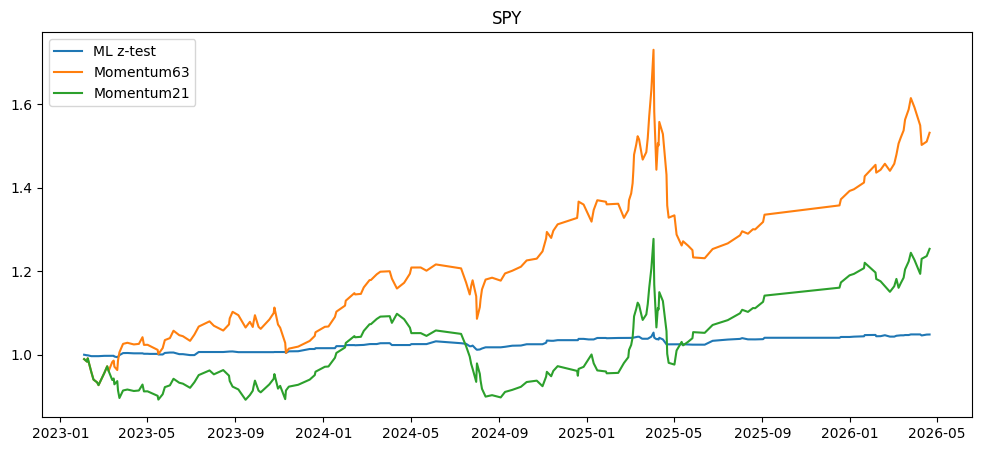

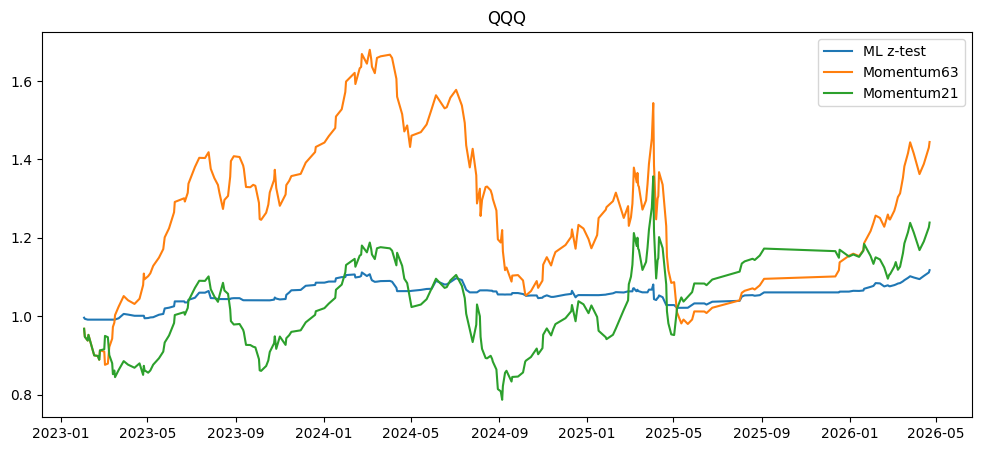

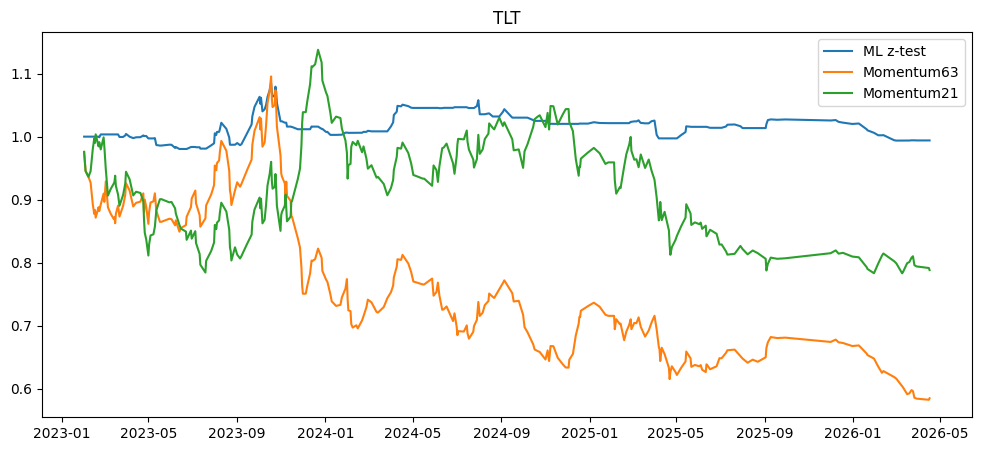

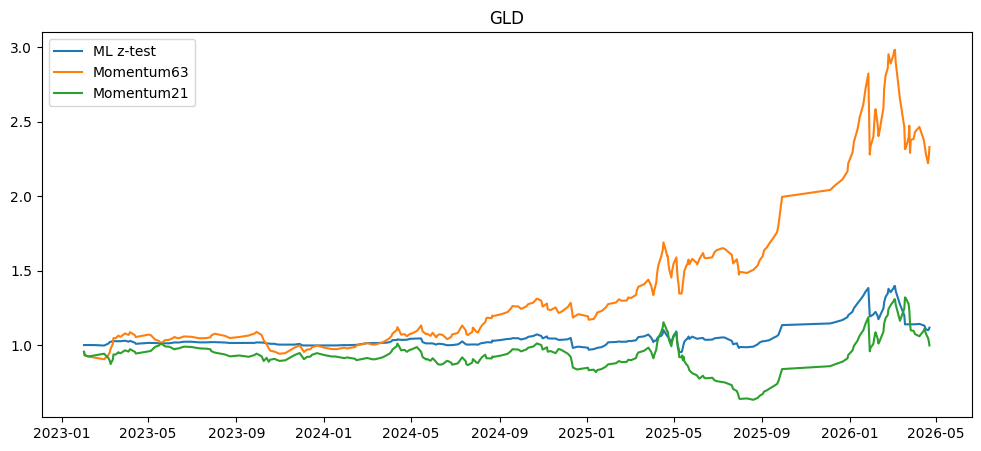

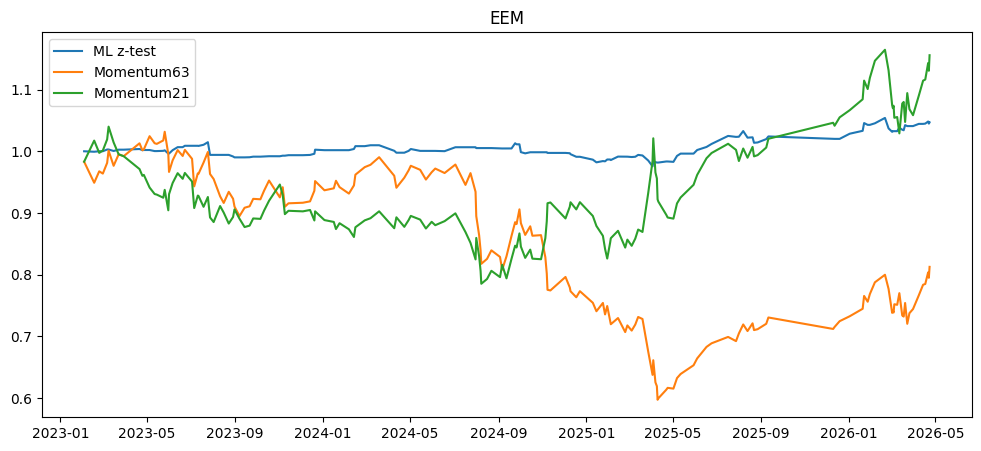

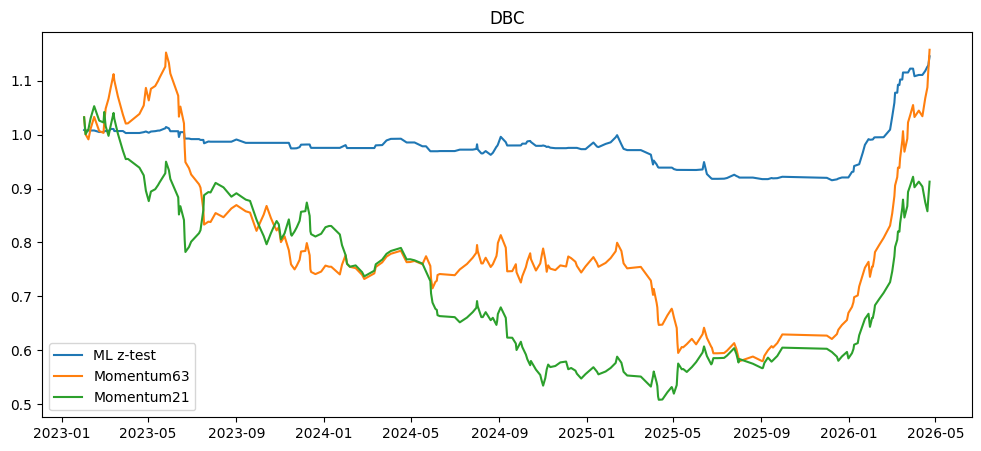

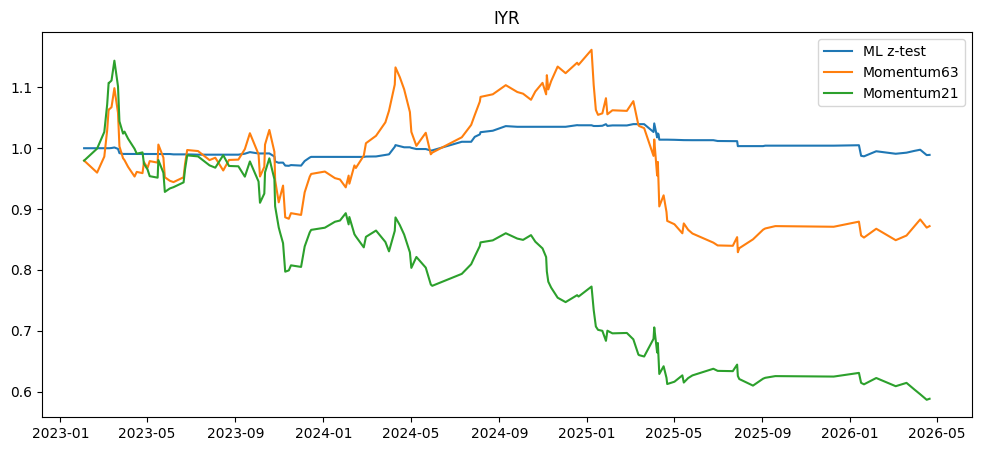

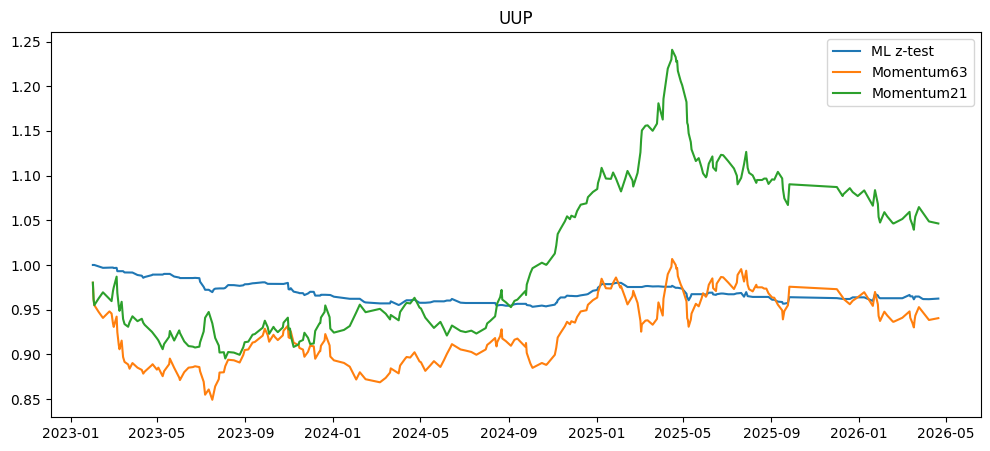

In [151]:
for tkr in tickers:

    df = wf_results[tkr].copy()

    df = df.sort_values('date')

    plt.figure(figsize=(12,5))

    eq_ml = (1+df['ml_ret']).cumprod()
    eq_m63 = (1+df['mom63_ret']).cumprod()
    eq_m21 = (1+df['mom21_ret']).cumprod()

    plt.plot(df['date'],eq_ml,label='ML z-test')
    plt.plot(df['date'],eq_m63,label='Momentum63')
    plt.plot(df['date'],eq_m21,label='Momentum21')

    plt.title(tkr)
    plt.legend()

    plt.show()

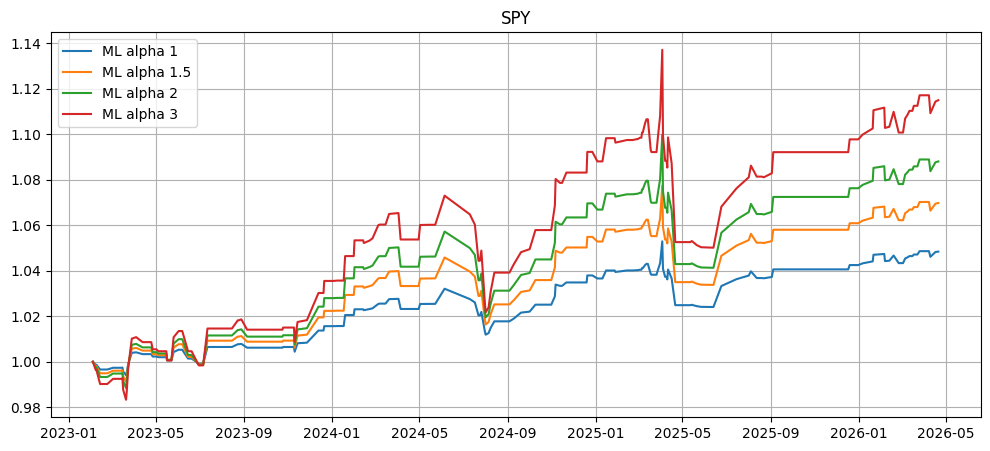

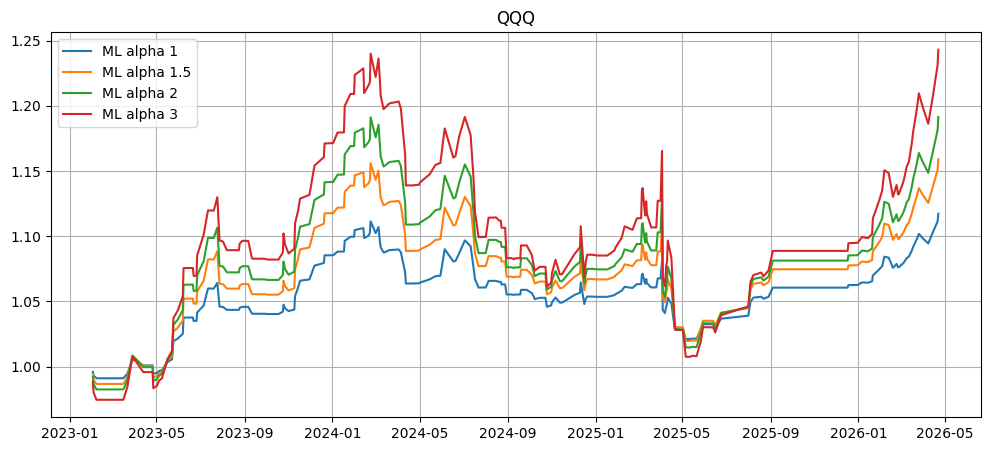

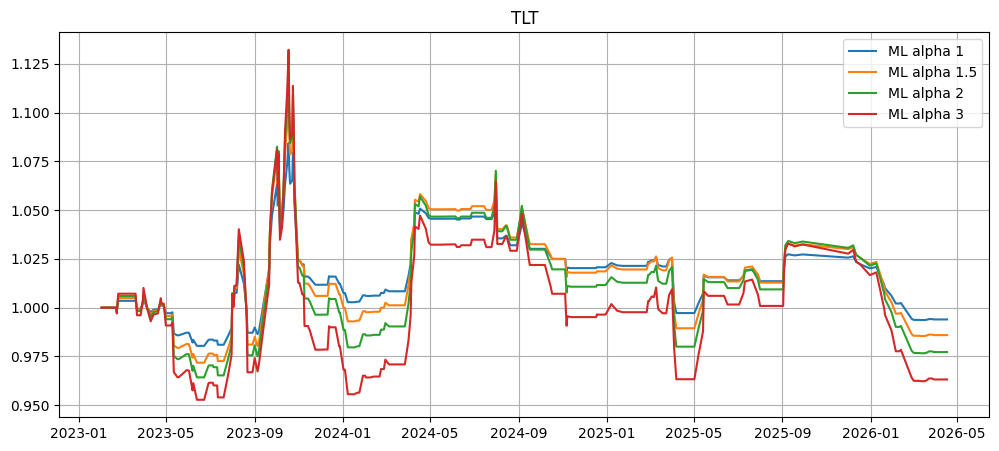

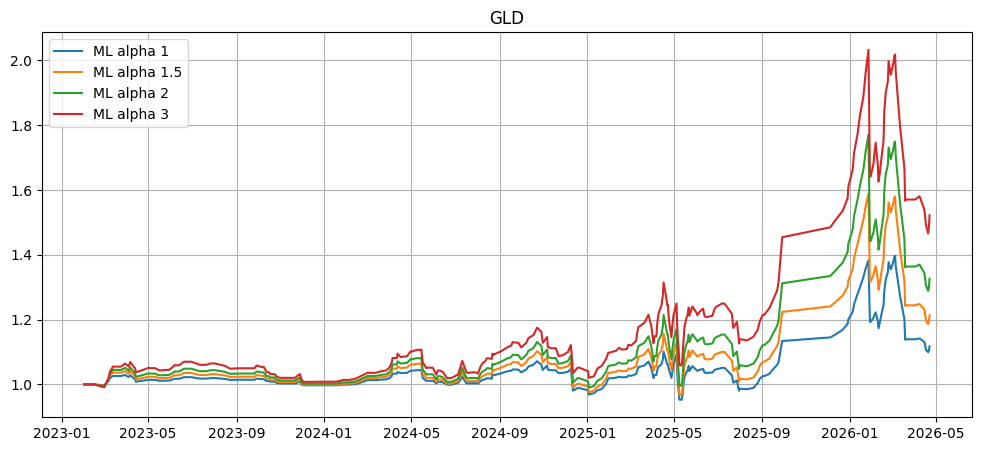

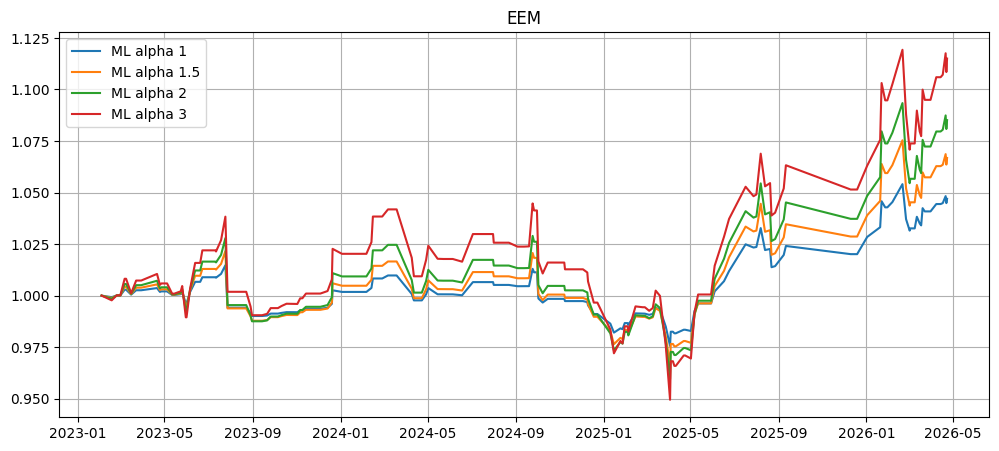

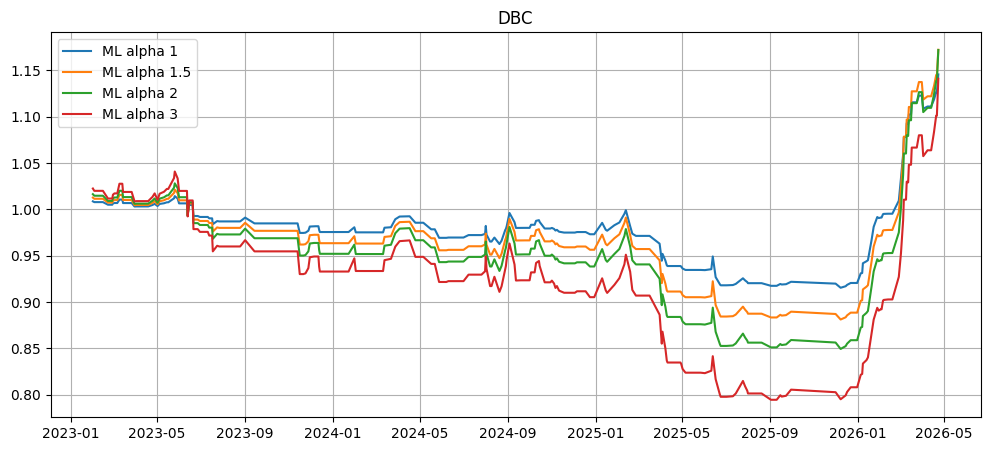

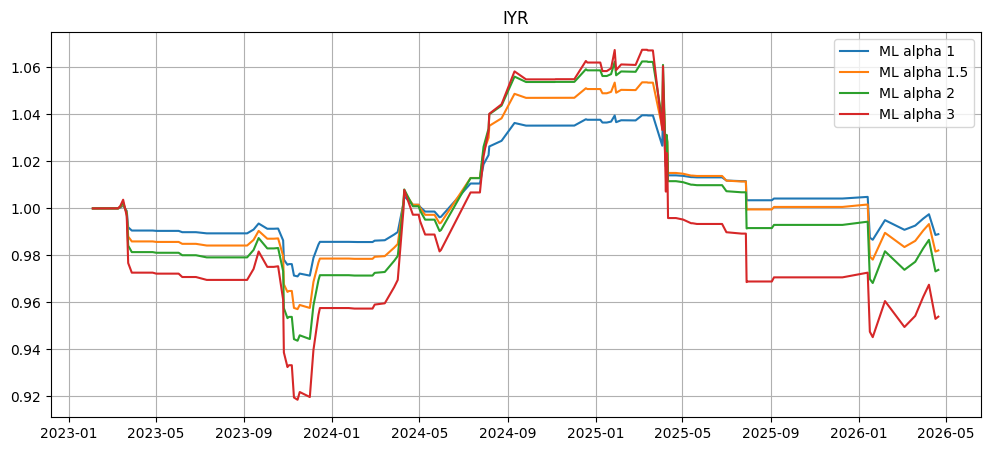

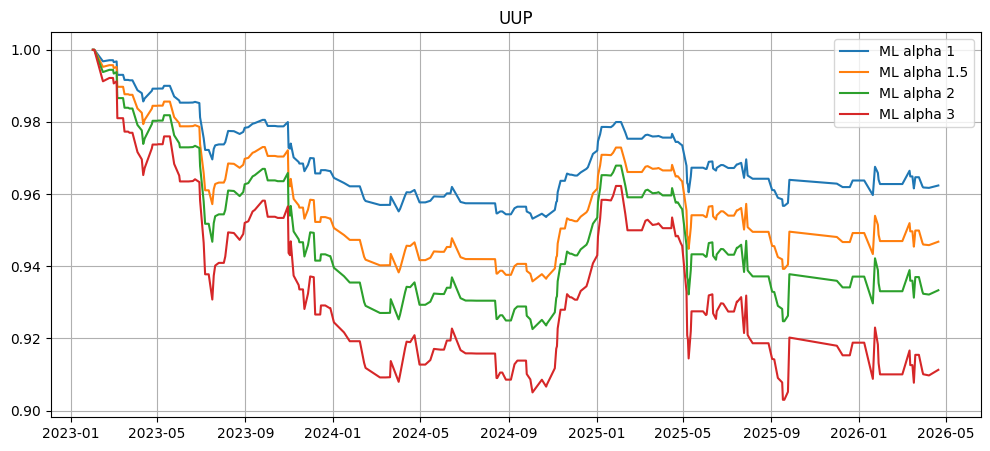

In [152]:
for tkr in tickers:
    df = wf_results[tkr].copy()
    df = df.sort_values('date')

    plt.figure(figsize=(12,5))

    eq_base = (1+df['ml_ret']).cumprod()
    eq_15 = (1+df['ml_ret_conf_15']).cumprod()
    eq_20 = (1+df['ml_ret_conf_20']).cumprod()
    eq_30 = (1+df['ml_ret_conf_30']).cumprod()

    plt.plot(df['date'],eq_base,label='ML alpha 1')
    plt.plot(df['date'],eq_15,label='ML alpha 1.5')
    plt.plot(df['date'],eq_20,label='ML alpha 2')
    plt.plot(df['date'],eq_30,label='ML alpha 3')

    plt.title(tkr)
    plt.legend()
    plt.grid(True)

    plt.show()

In [ ]:
for tkr in tickers:
    df = wf_results[tkr]

    print(tkr,'avg bet size =', round(df['bet_size'].mean(),4))

SPY avg bet size = 0.104
QQQ avg bet size = 0.1686
TLT avg bet size = 0.1439
GLD avg bet size = 0.3635
EEM avg bet size = 0.135
DBC avg bet size = 0.1774
IYR avg bet size = 0.0967
UUP avg bet size = 0.1552
